## Notebook to calculate Autocorrelation function (ACF) for all solvent-water mixtures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
import seaborn as sns
import colorsys

In [2]:
%%bash
pwd
ls -ltr

/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/Collaboration-projects/COR_HF/CMD_Rev
total 4136
-rw-------@  1 riteshk  staff      350 Aug 18  2022 acn.xyz
-rw-------@  1 riteshk  staff      933 Aug 18  2022 acn.ff
-rw-------@  1 riteshk  staff      185 Aug 21  2022 water.xyz
-rw-------@  1 riteshk  staff      296 Aug 21  2022 water.ff
-rw-------@  1 riteshk  staff    58214 Dec 30  2023 old_gen_solv-dist_Hbond_ACN_high.ipynb
-rw-------@  1 riteshk  staff     3019 Dec 30  2023 tba.xyz
-rw-------@  1 riteshk  staff      296 Dec 30  2023 clo4.xyz
-rw-------@  1 riteshk  staff      632 Dec 30  2023 clo4.ff
-rw-------@  1 riteshk  staff   124147 Dec 30  2023 fftool_cor_rev
drwx------   7 riteshk  staff      224 Dec 31  2023 molecular-ff-gen
-rw-------@  1 riteshk  staff    16506 Dec 31  2023 tba.ff
-rw-------@  1 riteshk  staff   315047 Jan  8  2024 old_gen-box-sim_acn.ipynb
-rw-------@  1 riteshk  staff     2084 Jan 12  2024 dmso.ff
-rw-------@  1 riteshk  staff      577 Jan 

-rw-------@  1 riteshk  staff     2719 Jan 12  2024 dmf.ff
-rw-------@  1 riteshk  staff      687 Jan 12  2024 dmf.xyz
-rw-------@  1 riteshk  staff     3986 Jan 12  2024 thf.ff
-rw-------@  1 riteshk  staff      743 Jan 12  2024 thf.xyz
-rw-------@  1 riteshk  staff  8399958 Jan 18  2024 gen-box-sim_dmso.ipynb
-rw-------@  1 riteshk  staff   578503 Jan 19  2024 gen-box-sim_acn.ipynb
-rw-------@  1 riteshk  staff      342 Feb  1  2024 test_water_conc_COR.csv
-rw-------@  1 riteshk  staff     2449 Feb  1  2024 data_water_conc_COR.csv
drwx------   7 riteshk  staff      224 Mar  2  2024 TBAClO4-water_x0-solv
drwx------   6 riteshk  staff      192 Mar  3  2024 TBAClO4-water_xl2-solv
-rw-------@  1 riteshk  staff  3154703 Mar  4  2024 gen-box-sim_dmf.ipynb
-rw-------@  1 riteshk  staff   212895 Mar  4  2024 RiteshKumar_updates_COR.pptx
-rw-------@  1 riteshk  staff  7487926 Mar  4  2024 gen-box-sim_thf.ipynb
drwx------   6 riteshk  staff      192 Mar  4  2024 TBAClO4-water_xl3-solv
drwx----

In [6]:
%%bash
ls acf-data/

acf_fit_acn-water_0_25.csv
acf_fit_acn-water_0_5.csv
acf_fit_acn-water_l1.csv
acf_fit_acn-water_l2.csv
acf_fit_acn-water_l3.csv
acf_fit_acn-water_l4.csv
acf_fit_acn-water_l5.csv
acf_fit_acn-water_l6.csv
acf_fit_dmf-water_l1.csv
acf_fit_dmf-water_l2.csv
acf_fit_dmf-water_l3.csv
acf_fit_dmf-water_l4.csv
acf_fit_dmf-water_l5.csv
acf_fit_dmf-water_l6.csv
acf_fit_dmf-water_x0.25.csv
acf_fit_dmf-water_x0.5.csv
acf_fit_dmso-water_l1.csv
acf_fit_dmso-water_l2.csv
acf_fit_dmso-water_l3.csv
acf_fit_dmso-water_l4.csv
acf_fit_dmso-water_l5.csv
acf_fit_dmso-water_l6.csv
acf_fit_dmso-water_x0.25.csv
acf_fit_dmso-water_x0.5.csv
acf_fit_thf-water_0_25.csv
acf_fit_thf-water_0_5.csv
acf_fit_thf-water_l1.csv
acf_fit_thf-water_l2.csv
acf_fit_thf-water_l3.csv
acf_fit_thf-water_l4.csv
acf_fit_thf-water_l5.csv
acf_fit_thf-water_l6.csv


In [3]:
def gen_color_gradient(color):
    # Convert the RGB values to HSL
    r, g, b = color
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    # Decrease the lightness value by 10%
    l -= 0.05 ## + will increase intensity
    # Convert the HSL values back to RGB
    r_, g_, b_ = colorsys.hls_to_rgb(h, l, s)
    # Print the new color values
    # print(f"New color: ({r:.3f}, {g:.3f}, {b:.3f})")
    return (r_, g_, b_)

In [7]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118

### ACF plot for ACN-water mixtures: using tau_frame = 25 & dt = 1 => ignore

In [4]:
df_acn_l1 = pd.read_csv('acf-data/acf_fit_acn-water_l1.csv')
df_acn_l2 = pd.read_csv('acf-data/acf_fit_acn-water_l2.csv')
df_acn_l3 = pd.read_csv('acf-data/acf_fit_acn-water_l3.csv')
df_acn_l4 = pd.read_csv('acf-data/acf_fit_acn-water_l4.csv')
df_acn_l5 = pd.read_csv('acf-data/acf_fit_acn-water_l5.csv')
df_acn_l6 = pd.read_csv('acf-data/acf_fit_acn-water_l6.csv')
df_acn_0_25 = pd.read_csv('acf-data/acf_fit_acn-water_0_25.csv')
df_acn_0_5 = pd.read_csv('acf-data/acf_fit_acn-water_0_5.csv')
df_acn_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.000000,1.000000e+00,0.000000,9.999975e-01
1,0.020396,0.437664,0.025025,8.716643e-01,0.025025,9.782060e-01
2,0.000464,0.203747,0.050050,7.722398e-01,0.050050,9.569770e-01
3,0.000009,0.096332,0.075075,6.912249e-01,0.075075,9.362925e-01
4,0.000000,0.046054,0.100100,6.226609e-01,0.100100,9.161354e-01
...,...,...,...,...,...,...
995,NaN,NaN,24.899900,1.118844e-41,24.899900,9.690358e-09
996,NaN,NaN,24.924925,1.017795e-41,24.924925,9.513593e-09
997,NaN,NaN,24.949950,9.258728e-42,24.949950,9.340053e-09
998,NaN,NaN,24.974975,8.422525e-42,24.974975,9.169678e-09


In [5]:
acn_1 = blue
acn_2 = gen_color_gradient(blue)
acn_3 = gen_color_gradient(acn_2)
acn_4 = gen_color_gradient(acn_3)
acn_5 = gen_color_gradient(acn_4)
acn_6 = gen_color_gradient(acn_5)
acn_7 = gen_color_gradient(acn_6)
acn_8 = gen_color_gradient(acn_7)

In [6]:
acf_acn_l1_ws = df_acn_l1['acf_ws'].loc[df_acn_l1['acf_ws'].notna()]; acf_acn_l1_ww = df_acn_l1['acf_ww'].loc[df_acn_l1['acf_ww'].notna()]
acf_acn_l2_ws = df_acn_l2['acf_ws'].loc[df_acn_l2['acf_ws'].notna()]; acf_acn_l2_ww = df_acn_l2['acf_ww'].loc[df_acn_l2['acf_ww'].notna()]
acf_acn_l3_ws = df_acn_l3['acf_ws'].loc[df_acn_l3['acf_ws'].notna()]; acf_acn_l3_ww = df_acn_l3['acf_ww'].loc[df_acn_l3['acf_ww'].notna()]
acf_acn_l4_ws = df_acn_l4['acf_ws'].loc[df_acn_l4['acf_ws'].notna()]; acf_acn_l4_ww = df_acn_l4['acf_ww'].loc[df_acn_l4['acf_ww'].notna()]
acf_acn_l5_ws = df_acn_l5['acf_ws'].loc[df_acn_l5['acf_ws'].notna()]; acf_acn_l5_ww = df_acn_l5['acf_ww'].loc[df_acn_l5['acf_ww'].notna()]
acf_acn_l6_ws = df_acn_l6['acf_ws'].loc[df_acn_l6['acf_ws'].notna()]; acf_acn_l6_ww = df_acn_l6['acf_ww'].loc[df_acn_l6['acf_ww'].notna()]
acf_acn_0_25_ws = df_acn_0_25['acf_ws'].loc[df_acn_0_25['acf_ws'].notna()]; acf_acn_0_25_ww = df_acn_0_25['acf_ww'].loc[df_acn_0_25['acf_ww'].notna()]
acf_acn_0_5_ws = df_acn_0_5['acf_ws'].loc[df_acn_0_5['acf_ws'].notna()]; acf_acn_0_5_ww = df_acn_0_5['acf_ww'].loc[df_acn_0_5['acf_ww'].notna()]
acf_acn_0_25_ws

0     1.000000
1     0.019139
2     0.000401
3     0.000010
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.000000
11    0.000000
12    0.000000
13    0.000000
14    0.000000
15    0.000000
16    0.000000
17    0.000000
18    0.000000
19    0.000000
20    0.000000
21    0.000000
22    0.000000
23    0.000000
24    0.000000
25    0.000000
Name: acf_ws, dtype: float64

In [7]:
fit_t_acn_l1_ws = df_acn_l1['fit_t_ws'].loc[df_acn_l1['fit_t_ws'].notna()]; fit_t_acn_l1_ww = df_acn_l1['fit_t_ws'].loc[df_acn_l1['fit_t_ws'].notna()]
fit_t_acn_l2_ws = df_acn_l2['fit_t_ws'].loc[df_acn_l2['fit_t_ws'].notna()]; fit_t_acn_l2_ww = df_acn_l2['fit_t_ws'].loc[df_acn_l2['fit_t_ws'].notna()]
fit_t_acn_l3_ws = df_acn_l3['fit_t_ws'].loc[df_acn_l3['fit_t_ws'].notna()]; fit_t_acn_l3_ww = df_acn_l3['fit_t_ws'].loc[df_acn_l3['fit_t_ws'].notna()]
fit_t_acn_l4_ws = df_acn_l4['fit_t_ws'].loc[df_acn_l4['fit_t_ws'].notna()]; fit_t_acn_l4_ww = df_acn_l4['fit_t_ws'].loc[df_acn_l4['fit_t_ws'].notna()]
fit_t_acn_l5_ws = df_acn_l5['fit_t_ws'].loc[df_acn_l5['fit_t_ws'].notna()]; fit_t_acn_l5_ww = df_acn_l5['fit_t_ws'].loc[df_acn_l5['fit_t_ws'].notna()]
fit_t_acn_l6_ws = df_acn_l6['fit_t_ws'].loc[df_acn_l6['fit_t_ws'].notna()]; fit_t_acn_l6_ww = df_acn_l6['fit_t_ws'].loc[df_acn_l6['fit_t_ws'].notna()]
fit_t_acn_0_25_ws = df_acn_0_25['fit_t_ws'].loc[df_acn_0_25['fit_t_ws'].notna()]; fit_t_acn_0_25_ww = df_acn_0_25['fit_t_ws'].loc[df_acn_0_25['fit_t_ws'].notna()]
fit_t_acn_0_5_ws = df_acn_0_5['fit_t_ws'].loc[df_acn_0_5['fit_t_ws'].notna()]; fit_t_acn_0_5_ww = df_acn_0_5['fit_t_ws'].loc[df_acn_0_5['fit_t_ws'].notna()]
fit_t_acn_0_5_ww

0       0.000000
1       0.025025
2       0.050050
3       0.075075
4       0.100100
         ...    
995    24.899900
996    24.924925
997    24.949950
998    24.974975
999    25.000000
Name: fit_t_ws, Length: 1000, dtype: float64

In [8]:
fit_acf_acn_l1_ws = df_acn_l1['fit_acf_ws'].loc[df_acn_l1['fit_acf_ws'].notna()]; fit_acf_acn_l1_ww = df_acn_l1['fit_acf_ww'].loc[df_acn_l1['fit_acf_ww'].notna()]  
fit_acf_acn_l2_ws = df_acn_l2['fit_acf_ws'].loc[df_acn_l2['fit_acf_ws'].notna()]; fit_acf_acn_l2_ww = df_acn_l2['fit_acf_ww'].loc[df_acn_l2['fit_acf_ww'].notna()]
fit_acf_acn_l3_ws = df_acn_l3['fit_acf_ws'].loc[df_acn_l3['fit_acf_ws'].notna()]; fit_acf_acn_l3_ww = df_acn_l3['fit_acf_ww'].loc[df_acn_l3['fit_acf_ww'].notna()]
fit_acf_acn_l4_ws = df_acn_l4['fit_acf_ws'].loc[df_acn_l4['fit_acf_ws'].notna()]; fit_acf_acn_l4_ww = df_acn_l4['fit_acf_ww'].loc[df_acn_l4['fit_acf_ww'].notna()]
fit_acf_acn_l5_ws = df_acn_l5['fit_acf_ws'].loc[df_acn_l5['fit_acf_ws'].notna()]; fit_acf_acn_l5_ww = df_acn_l5['fit_acf_ww'].loc[df_acn_l5['fit_acf_ww'].notna()]
fit_acf_acn_l6_ws = df_acn_l6['fit_acf_ws'].loc[df_acn_l6['fit_acf_ws'].notna()]; fit_acf_acn_l6_ww = df_acn_l6['fit_acf_ww'].loc[df_acn_l6['fit_acf_ww'].notna()]
fit_acf_acn_0_25_ws = df_acn_0_25['fit_acf_ws'].loc[df_acn_0_25['fit_acf_ws'].notna()]; fit_acf_acn_0_25_ww = df_acn_0_25['fit_acf_ww'].loc[df_acn_0_25['fit_acf_ww'].notna()]
fit_acf_acn_0_5_ws = df_acn_0_5['fit_acf_ws'].loc[df_acn_0_5['fit_acf_ws'].notna()]; fit_acf_acn_0_5_ww = df_acn_0_5['fit_acf_ww'].loc[df_acn_0_5['fit_acf_ww'].notna()]
fit_acf_acn_0_5_ww

0      9.999999e-01
1      9.497794e-01
2      9.022276e-01
3      8.571976e-01
4      8.145510e-01
           ...     
995    2.589850e-14
996    2.513118e-14
997    2.438660e-14
998    2.366408e-14
999    2.296297e-14
Name: fit_acf_ww, Length: 1000, dtype: float64

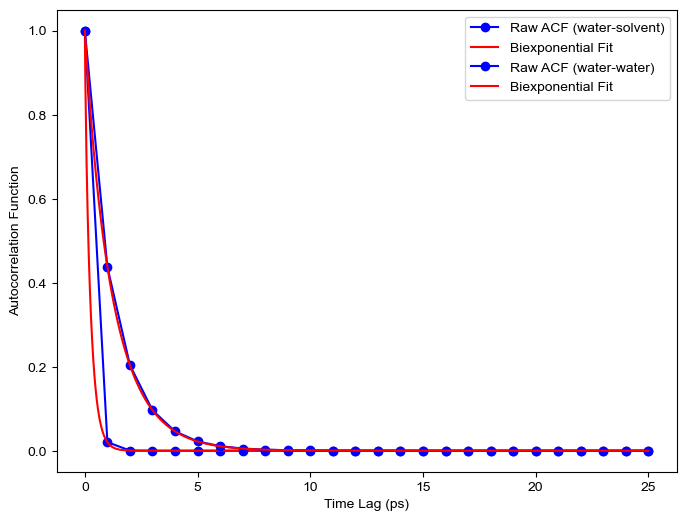

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(acf_acn_l1_ws)), acf_acn_l1_ws, 'bo-', label="Raw ACF (water-solvent)")
plt.plot(fit_t_acn_l1_ws, fit_acf_acn_l1_ws, 'r-', label="Biexponential Fit")
plt.plot(np.arange(len(acf_acn_l1_ww)), acf_acn_l1_ww, 'bo-', label="Raw ACF (water-water)")
plt.plot(fit_t_acn_l1_ww, fit_acf_acn_l1_ww, 'r-', label="Biexponential Fit")
plt.xlabel("Time Lag (ps)")
plt.ylabel("Autocorrelation Function")
# plt.title("ACF of H-bond Lifetimes for Cosolvent 1")
plt.legend()
plt.show()

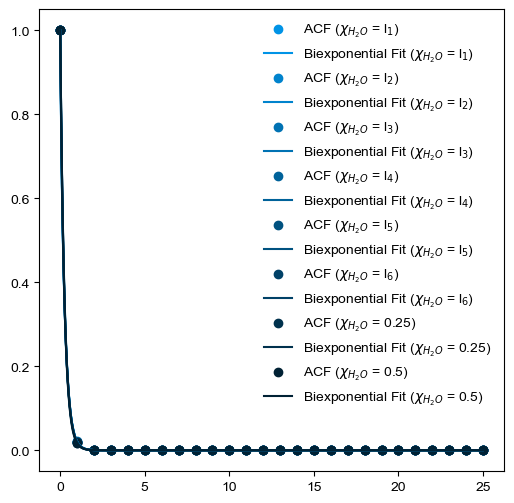

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_acn_l1_ws)), acf_acn_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.plot(fit_t_acn_l1_ws, fit_acf_acn_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.scatter(np.arange(len(acf_acn_l2_ws)), acf_acn_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.plot(fit_t_acn_l2_ws, fit_acf_acn_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.scatter(np.arange(len(acf_acn_l3_ws)), acf_acn_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.plot(fit_t_acn_l3_ws, fit_acf_acn_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.scatter(np.arange(len(acf_acn_l4_ws)), acf_acn_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.plot(fit_t_acn_l4_ws, fit_acf_acn_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.scatter(np.arange(len(acf_acn_l5_ws)), acf_acn_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.plot(fit_t_acn_l5_ws, fit_acf_acn_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.scatter(np.arange(len(acf_acn_l6_ws)), acf_acn_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.plot(fit_t_acn_l6_ws, fit_acf_acn_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.scatter(np.arange(len(acf_acn_0_25_ws)), acf_acn_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.plot(fit_t_acn_0_25_ws, fit_acf_acn_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.scatter(np.arange(len(acf_acn_0_5_ws)), acf_acn_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)
plt.plot(fit_t_acn_0_5_ws, fit_acf_acn_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)

plt.legend(frameon=False)

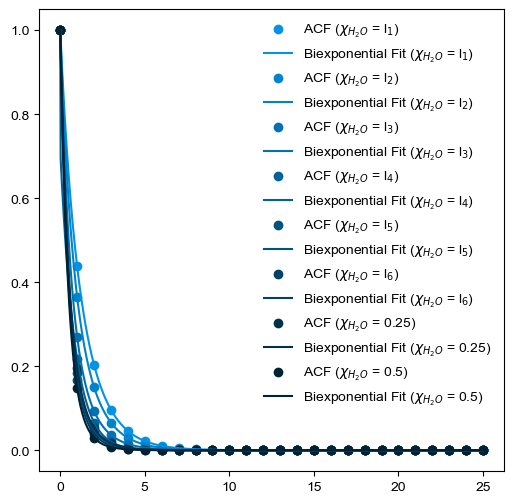

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_acn_l1_ww)), acf_acn_l1_ww, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.plot(fit_t_acn_l1_ww, fit_acf_acn_l1_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.scatter(np.arange(len(acf_acn_l2_ww)), acf_acn_l2_ww, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.plot(fit_t_acn_l2_ww, fit_acf_acn_l2_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.scatter(np.arange(len(acf_acn_l3_ww)), acf_acn_l3_ww, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.plot(fit_t_acn_l3_ww, fit_acf_acn_l3_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.scatter(np.arange(len(acf_acn_l4_ww)), acf_acn_l4_ww, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.plot(fit_t_acn_l4_ww, fit_acf_acn_l4_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.scatter(np.arange(len(acf_acn_l5_ww)), acf_acn_l5_ww, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.plot(fit_t_acn_l5_ww, fit_acf_acn_l5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.scatter(np.arange(len(acf_acn_l6_ww)), acf_acn_l6_ww, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.plot(fit_t_acn_l6_ww, fit_acf_acn_l6_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.scatter(np.arange(len(acf_acn_0_25_ww)), acf_acn_0_25_ww, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.plot(fit_t_acn_0_25_ww, fit_acf_acn_0_25_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.scatter(np.arange(len(acf_acn_0_5_ww)), acf_acn_0_5_ww, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)
plt.plot(fit_t_acn_0_5_ww, fit_acf_acn_0_5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)
plt.legend(frameon=False)

### ACF plot for DMSO-water mixtures

In [14]:
df_dmso_l1 = pd.read_csv('acf-data/acf_fit_dmso-water_l1.csv')
df_dmso_l2 = pd.read_csv('acf-data/acf_fit_dmso-water_l2.csv')
df_dmso_l3 = pd.read_csv('acf-data/acf_fit_dmso-water_l3.csv')
df_dmso_l4 = pd.read_csv('acf-data/acf_fit_dmso-water_l4.csv')
df_dmso_l5 = pd.read_csv('acf-data/acf_fit_dmso-water_l5.csv')
df_dmso_l6 = pd.read_csv('acf-data/acf_fit_dmso-water_l6.csv')
df_dmso_0_25 = pd.read_csv('acf-data/acf_fit_dmso-water_0_25.csv')
df_dmso_0_5 = pd.read_csv('acf-data/acf_fit_dmso-water_0_5.csv')
df_dmso_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.000000,1.005624,0.000000,0.995174
1,0.933441,0.794154,0.025025,1.003784,0.025025,0.989654
2,0.872875,0.636886,0.050050,1.001949,0.050050,0.984166
3,0.817569,0.513639,0.075075,1.000118,0.075075,0.978710
4,0.767059,0.416611,0.100100,0.998292,0.100100,0.973285
...,...,...,...,...,...,...
995,NaN,NaN,24.899900,0.338279,24.899900,0.027363
996,NaN,NaN,24.924925,0.338132,24.924925,0.027329
997,NaN,NaN,24.949950,0.337985,24.949950,0.027296
998,NaN,NaN,24.974975,0.337839,24.974975,0.027262


In [15]:
dmso_1 = orange
dmso_2 = gen_color_gradient(orange)
dmso_3 = gen_color_gradient(dmso_2)
dmso_4 = gen_color_gradient(dmso_3)
dmso_5 = gen_color_gradient(dmso_4)
dmso_6 = gen_color_gradient(dmso_5)
dmso_7 = gen_color_gradient(dmso_6)
dmso_8 = gen_color_gradient(dmso_7)

In [17]:
acf_dmso_l1_ws = df_dmso_l1['acf_ws'].loc[df_dmso_l1['acf_ws'].notna()]; acf_dmso_l1_ww = df_dmso_l1['acf_ww'].loc[df_dmso_l1['acf_ww'].notna()]
acf_dmso_l2_ws = df_dmso_l2['acf_ws'].loc[df_dmso_l2['acf_ws'].notna()]; acf_dmso_l2_ww = df_dmso_l2['acf_ww'].loc[df_dmso_l2['acf_ww'].notna()]
acf_dmso_l3_ws = df_dmso_l3['acf_ws'].loc[df_dmso_l3['acf_ws'].notna()]; acf_dmso_l3_ww = df_dmso_l3['acf_ww'].loc[df_dmso_l3['acf_ww'].notna()]
acf_dmso_l4_ws = df_dmso_l4['acf_ws'].loc[df_dmso_l4['acf_ws'].notna()]; acf_dmso_l4_ww = df_dmso_l4['acf_ww'].loc[df_dmso_l4['acf_ww'].notna()]
acf_dmso_l5_ws = df_dmso_l5['acf_ws'].loc[df_dmso_l5['acf_ws'].notna()]; acf_dmso_l5_ww = df_dmso_l5['acf_ww'].loc[df_dmso_l5['acf_ww'].notna()]
acf_dmso_l6_ws = df_dmso_l6['acf_ws'].loc[df_dmso_l6['acf_ws'].notna()]; acf_dmso_l6_ww = df_dmso_l6['acf_ww'].loc[df_dmso_l6['acf_ww'].notna()]
acf_dmso_0_25_ws = df_dmso_0_25['acf_ws'].loc[df_dmso_0_25['acf_ws'].notna()]; acf_dmso_0_25_ww = df_dmso_0_25['acf_ww'].loc[df_dmso_0_25['acf_ww'].notna()]
acf_dmso_0_5_ws = df_dmso_0_5['acf_ws'].loc[df_dmso_0_5['acf_ws'].notna()]; acf_dmso_0_5_ww = df_dmso_0_5['acf_ww'].loc[df_dmso_0_5['acf_ww'].notna()]
acf_dmso_0_5_ww

0     1.000000
1     0.806143
2     0.661550
3     0.547764
4     0.456496
5     0.382520
6     0.322107
7     0.272521
8     0.231626
9     0.197781
10    0.169682
11    0.146272
12    0.126749
13    0.110463
14    0.096870
15    0.085533
16    0.076075
17    0.068204
18    0.061685
19    0.056357
20    0.052071
21    0.048713
22    0.046222
23    0.044575
24    0.043811
25    0.044107
Name: acf_ww, dtype: float64

In [18]:
fit_t_dmso_l1_ws = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]; fit_t_dmso_l1_ww = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]
fit_t_dmso_l2_ws = df_dmso_l2['fit_t_ws'].loc[df_dmso_l2['fit_t_ws'].notna()]; fit_t_dmso_l2_ww = df_dmso_l2['fit_t_ws'].loc[df_dmso_l2['fit_t_ws'].notna()]
fit_t_dmso_l3_ws = df_dmso_l3['fit_t_ws'].loc[df_dmso_l3['fit_t_ws'].notna()]; fit_t_dmso_l3_ww = df_dmso_l3['fit_t_ws'].loc[df_dmso_l3['fit_t_ws'].notna()]
fit_t_dmso_l4_ws = df_dmso_l4['fit_t_ws'].loc[df_dmso_l4['fit_t_ws'].notna()]; fit_t_dmso_l4_ww = df_dmso_l4['fit_t_ws'].loc[df_dmso_l4['fit_t_ws'].notna()]
fit_t_dmso_l5_ws = df_dmso_l5['fit_t_ws'].loc[df_dmso_l5['fit_t_ws'].notna()]; fit_t_dmso_l5_ww = df_dmso_l5['fit_t_ws'].loc[df_dmso_l5['fit_t_ws'].notna()]
fit_t_dmso_l6_ws = df_dmso_l6['fit_t_ws'].loc[df_dmso_l6['fit_t_ws'].notna()]; fit_t_dmso_l6_ww = df_dmso_l6['fit_t_ws'].loc[df_dmso_l6['fit_t_ws'].notna()]
fit_t_dmso_0_25_ws = df_dmso_0_25['fit_t_ws'].loc[df_dmso_0_25['fit_t_ws'].notna()]; fit_t_dmso_0_25_ww = df_dmso_0_25['fit_t_ws'].loc[df_dmso_0_25['fit_t_ws'].notna()]
fit_t_dmso_0_5_ws = df_dmso_0_5['fit_t_ws'].loc[df_dmso_0_5['fit_t_ws'].notna()]; fit_t_dmso_0_5_ww = df_dmso_0_5['fit_t_ws'].loc[df_dmso_0_5['fit_t_ws'].notna()]
fit_t_dmso_0_5_ww

0       0.000000
1       0.025025
2       0.050050
3       0.075075
4       0.100100
         ...    
995    24.899900
996    24.924925
997    24.949950
998    24.974975
999    25.000000
Name: fit_t_ws, Length: 1000, dtype: float64

In [20]:
fit_acf_dmso_l1_ws = df_dmso_l1['fit_acf_ws'].loc[df_dmso_l1['fit_acf_ws'].notna()]; fit_acf_dmso_l1_ww = df_dmso_l1['fit_acf_ww'].loc[df_dmso_l1['fit_acf_ww'].notna()]
fit_acf_dmso_l2_ws = df_dmso_l2['fit_acf_ws'].loc[df_dmso_l2['fit_acf_ws'].notna()]; fit_acf_dmso_l2_ww = df_dmso_l2['fit_acf_ww'].loc[df_dmso_l2['fit_acf_ww'].notna()]
fit_acf_dmso_l3_ws = df_dmso_l3['fit_acf_ws'].loc[df_dmso_l3['fit_acf_ws'].notna()]; fit_acf_dmso_l3_ww = df_dmso_l3['fit_acf_ww'].loc[df_dmso_l3['fit_acf_ww'].notna()]
fit_acf_dmso_l4_ws = df_dmso_l4['fit_acf_ws'].loc[df_dmso_l4['fit_acf_ws'].notna()]; fit_acf_dmso_l4_ww = df_dmso_l4['fit_acf_ww'].loc[df_dmso_l4['fit_acf_ww'].notna()]
fit_acf_dmso_l5_ws = df_dmso_l5['fit_acf_ws'].loc[df_dmso_l5['fit_acf_ws'].notna()]; fit_acf_dmso_l5_ww = df_dmso_l5['fit_acf_ww'].loc[df_dmso_l5['fit_acf_ww'].notna()]
fit_acf_dmso_l6_ws = df_dmso_l6['fit_acf_ws'].loc[df_dmso_l6['fit_acf_ws'].notna()]; fit_acf_dmso_l6_ww = df_dmso_l6['fit_acf_ww'].loc[df_dmso_l6['fit_acf_ww'].notna()]
fit_acf_dmso_0_25_ws = df_dmso_0_25['fit_acf_ws'].loc[df_dmso_0_25['fit_acf_ws'].notna()]; fit_acf_dmso_0_25_ww = df_dmso_0_25['fit_acf_ww'].loc[df_dmso_0_25['fit_acf_ww'].notna()]
fit_acf_dmso_0_5_ws = df_dmso_0_5['fit_acf_ws'].loc[df_dmso_0_5['fit_acf_ws'].notna()]; fit_acf_dmso_0_5_ww = df_dmso_0_5['fit_acf_ww'].loc[df_dmso_0_5['fit_acf_ww'].notna()]
fit_acf_dmso_0_5_ww

0      0.992929
1      0.987912
2      0.982922
3      0.977960
4      0.973025
         ...   
995    0.037166
996    0.037101
997    0.037036
998    0.036971
999    0.036906
Name: fit_acf_ww, Length: 1000, dtype: float64

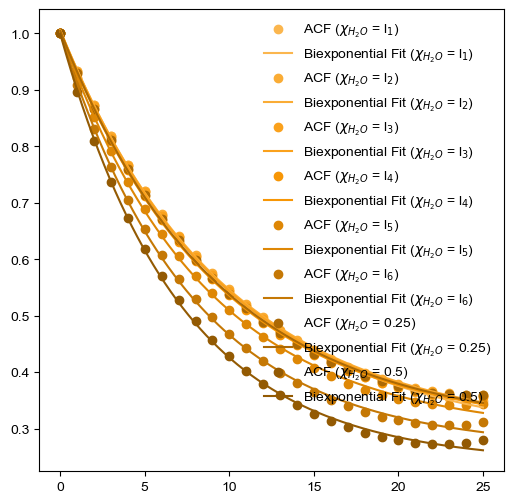

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmso_l1_ws)), acf_dmso_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.plot(fit_t_dmso_l1_ws, fit_acf_dmso_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.scatter(np.arange(len(acf_dmso_l2_ws)), acf_dmso_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.plot(fit_t_dmso_l2_ws, fit_acf_dmso_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.scatter(np.arange(len(acf_dmso_l3_ws)), acf_dmso_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.plot(fit_t_dmso_l3_ws, fit_acf_dmso_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.scatter(np.arange(len(acf_dmso_l4_ws)), acf_dmso_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.plot(fit_t_dmso_l4_ws, fit_acf_dmso_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.scatter(np.arange(len(acf_dmso_l5_ws)), acf_dmso_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.plot(fit_t_dmso_l5_ws, fit_acf_dmso_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.scatter(np.arange(len(acf_dmso_l6_ws)), acf_dmso_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.plot(fit_t_dmso_l6_ws, fit_acf_dmso_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.scatter(np.arange(len(acf_dmso_0_25_ws)), acf_dmso_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.plot(fit_t_dmso_0_25_ws, fit_acf_dmso_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.scatter(np.arange(len(acf_dmso_0_5_ws)), acf_dmso_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.plot(fit_t_dmso_0_5_ws, fit_acf_dmso_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.legend(frameon=False)

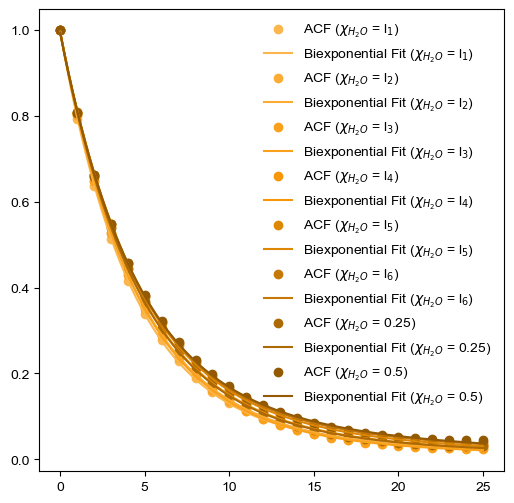

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmso_l1_ww)), acf_dmso_l1_ww, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.plot(fit_t_dmso_l1_ww, fit_acf_dmso_l1_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.scatter(np.arange(len(acf_dmso_l2_ww)), acf_dmso_l2_ww, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.plot(fit_t_dmso_l2_ww, fit_acf_dmso_l2_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.scatter(np.arange(len(acf_dmso_l3_ww)), acf_dmso_l3_ww, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.plot(fit_t_dmso_l3_ww, fit_acf_dmso_l3_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.scatter(np.arange(len(acf_dmso_l4_ww)), acf_dmso_l4_ww, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.plot(fit_t_dmso_l4_ww, fit_acf_dmso_l4_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.scatter(np.arange(len(acf_dmso_l5_ww)), acf_dmso_l5_ww, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.plot(fit_t_dmso_l5_ww, fit_acf_dmso_l5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.scatter(np.arange(len(acf_dmso_l6_ww)), acf_dmso_l6_ww, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.plot(fit_t_dmso_l6_ww, fit_acf_dmso_l6_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.scatter(np.arange(len(acf_dmso_0_25_ww)), acf_dmso_0_25_ww, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.plot(fit_t_dmso_0_25_ww, fit_acf_dmso_0_25_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.scatter(np.arange(len(acf_dmso_0_5_ww)), acf_dmso_0_5_ww, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.plot(fit_t_dmso_0_5_ww, fit_acf_dmso_0_5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.legend(frameon=False)

### ACF plot for DMF-water mixtures: using 25 frames => ignore

In [25]:
df_dmf_l1 = pd.read_csv('acf-data/acf_fit_dmf-water_l1.csv')
df_dmf_l2 = pd.read_csv('acf-data/acf_fit_dmf-water_l2.csv')
df_dmf_l3 = pd.read_csv('acf-data/acf_fit_dmf-water_l3.csv')
df_dmf_l4 = pd.read_csv('acf-data/acf_fit_dmf-water_l4.csv')
df_dmf_l5 = pd.read_csv('acf-data/acf_fit_dmf-water_l5.csv')
df_dmf_l6 = pd.read_csv('acf-data/acf_fit_dmf-water_l6.csv')
df_dmf_0_25 = pd.read_csv('acf-data/acf_fit_dmf-water_0_25.csv')
df_dmf_0_5 = pd.read_csv('acf-data/acf_fit_dmf-water_0_5.csv')
df_dmf_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.000000,9.999774e-01,0.000000,0.998184
1,0.470445,0.782728,0.025025,9.803438e-01,0.025025,0.992156
2,0.236346,0.618102,0.050050,9.611483e-01,0.050050,0.986167
3,0.122757,0.490621,0.075075,9.423798e-01,0.075075,0.980216
4,0.065220,0.391132,0.100100,9.240277e-01,0.100100,0.974304
...,...,...,...,...,...,...
995,NaN,NaN,24.899900,2.268566e-07,24.899900,0.007412
996,NaN,NaN,24.924925,2.234747e-07,24.924925,0.007382
997,NaN,NaN,24.949950,2.201432e-07,24.949950,0.007352
998,NaN,NaN,24.974975,2.168614e-07,24.974975,0.007321


In [26]:
dmf_1 = purple
dmf_2 = gen_color_gradient(purple)
dmf_3 = gen_color_gradient(dmf_2)
dmf_4 = gen_color_gradient(dmf_3)
dmf_5 = gen_color_gradient(dmf_4)
dmf_6 = gen_color_gradient(dmf_5)
dmf_7 = gen_color_gradient(dmf_6)
dmf_8 = gen_color_gradient(dmf_7)

In [28]:
acf_dmf_l1_ws = df_dmf_l1['acf_ws'].loc[df_dmf_l1['acf_ws'].notna()]; acf_dmf_l1_ww = df_dmf_l1['acf_ww'].loc[df_dmf_l1['acf_ww'].notna()]
acf_dmf_l2_ws = df_dmf_l2['acf_ws'].loc[df_dmf_l2['acf_ws'].notna()]; acf_dmf_l2_ww = df_dmf_l2['acf_ww'].loc[df_dmf_l2['acf_ww'].notna()]
acf_dmf_l3_ws = df_dmf_l3['acf_ws'].loc[df_dmf_l3['acf_ws'].notna()]; acf_dmf_l3_ww = df_dmf_l3['acf_ww'].loc[df_dmf_l3['acf_ww'].notna()]
acf_dmf_l4_ws = df_dmf_l4['acf_ws'].loc[df_dmf_l4['acf_ws'].notna()]; acf_dmf_l4_ww = df_dmf_l4['acf_ww'].loc[df_dmf_l4['acf_ww'].notna()]
acf_dmf_l5_ws = df_dmf_l5['acf_ws'].loc[df_dmf_l5['acf_ws'].notna()]; acf_dmf_l5_ww = df_dmf_l5['acf_ww'].loc[df_dmf_l5['acf_ww'].notna()]
acf_dmf_l6_ws = df_dmf_l6['acf_ws'].loc[df_dmf_l6['acf_ws'].notna()]; acf_dmf_l6_ww = df_dmf_l6['acf_ww'].loc[df_dmf_l6['acf_ww'].notna()]
acf_dmf_0_25_ws = df_dmf_0_25['acf_ws'].loc[df_dmf_0_25['acf_ws'].notna()]; acf_dmf_0_25_ww = df_dmf_0_25['acf_ww'].loc[df_dmf_0_25['acf_ww'].notna()]
acf_dmf_0_5_ws = df_dmf_0_5['acf_ws'].loc[df_dmf_0_5['acf_ws'].notna()]; acf_dmf_0_5_ww = df_dmf_0_5['acf_ww'].loc[df_dmf_0_5['acf_ww'].notna()]
acf_dmf_0_5_ww

0     1.000000
1     0.745142
2     0.573720
3     0.448151
4     0.353433
5     0.280801
6     0.224511
7     0.180545
8     0.145978
9     0.118649
10    0.096948
11    0.079647
12    0.065809
13    0.054726
14    0.045826
15    0.038656
16    0.032874
17    0.028215
18    0.024472
19    0.021482
20    0.019148
21    0.017369
22    0.016063
23    0.015194
24    0.014782
25    0.014920
Name: acf_ww, dtype: float64

In [29]:
fit_t_dmf_l1_ws = df_dmf_l1['fit_t_ws'].loc[df_dmf_l1['fit_t_ws'].notna()]; fit_t_dmf_l1_ww = df_dmf_l1['fit_t_ws'].loc[df_dmf_l1['fit_t_ws'].notna()]
fit_t_dmf_l2_ws = df_dmf_l2['fit_t_ws'].loc[df_dmf_l2['fit_t_ws'].notna()]; fit_t_dmf_l2_ww = df_dmf_l2['fit_t_ws'].loc[df_dmf_l2['fit_t_ws'].notna()]
fit_t_dmf_l3_ws = df_dmf_l3['fit_t_ws'].loc[df_dmf_l3['fit_t_ws'].notna()]; fit_t_dmf_l3_ww = df_dmf_l3['fit_t_ws'].loc[df_dmf_l3['fit_t_ws'].notna()]
fit_t_dmf_l4_ws = df_dmf_l4['fit_t_ws'].loc[df_dmf_l4['fit_t_ws'].notna()]; fit_t_dmf_l4_ww = df_dmf_l4['fit_t_ws'].loc[df_dmf_l4['fit_t_ws'].notna()]
fit_t_dmf_l5_ws = df_dmf_l5['fit_t_ws'].loc[df_dmf_l5['fit_t_ws'].notna()]; fit_t_dmf_l5_ww = df_dmf_l5['fit_t_ws'].loc[df_dmf_l5['fit_t_ws'].notna()]
fit_t_dmf_l6_ws = df_dmf_l6['fit_t_ws'].loc[df_dmf_l6['fit_t_ws'].notna()]; fit_t_dmf_l6_ww = df_dmf_l6['fit_t_ws'].loc[df_dmf_l6['fit_t_ws'].notna()]
fit_t_dmf_0_25_ws = df_dmf_0_25['fit_t_ws'].loc[df_dmf_0_25['fit_t_ws'].notna()]; fit_t_dmf_0_25_ww = df_dmf_0_25['fit_t_ws'].loc[df_dmf_0_25['fit_t_ws'].notna()]
fit_t_dmf_0_5_ws = df_dmf_0_5['fit_t_ws'].loc[df_dmf_0_5['fit_t_ws'].notna()]; fit_t_dmf_0_5_ww = df_dmf_0_5['fit_t_ws'].loc[df_dmf_0_5['fit_t_ws'].notna()]
fit_t_dmf_0_5_ww

0       0.000000
1       0.025025
2       0.050050
3       0.075075
4       0.100100
         ...    
995    24.899900
996    24.924925
997    24.949950
998    24.974975
999    25.000000
Name: fit_t_ws, Length: 1000, dtype: float64

In [30]:
fit_acf_dmf_l1_ws = df_dmf_l1['fit_acf_ws'].loc[df_dmf_l1['fit_acf_ws'].notna()]; fit_acf_dmf_l1_ww = df_dmf_l1['fit_acf_ww'].loc[df_dmf_l1['fit_acf_ww'].notna()]
fit_acf_dmf_l2_ws = df_dmf_l2['fit_acf_ws'].loc[df_dmf_l2['fit_acf_ws'].notna()]; fit_acf_dmf_l2_ww = df_dmf_l2['fit_acf_ww'].loc[df_dmf_l2['fit_acf_ww'].notna()]
fit_acf_dmf_l3_ws = df_dmf_l3['fit_acf_ws'].loc[df_dmf_l3['fit_acf_ws'].notna()]; fit_acf_dmf_l3_ww = df_dmf_l3['fit_acf_ww'].loc[df_dmf_l3['fit_acf_ww'].notna()]
fit_acf_dmf_l4_ws = df_dmf_l4['fit_acf_ws'].loc[df_dmf_l4['fit_acf_ws'].notna()]; fit_acf_dmf_l4_ww = df_dmf_l4['fit_acf_ww'].loc[df_dmf_l4['fit_acf_ww'].notna()]
fit_acf_dmf_l5_ws = df_dmf_l5['fit_acf_ws'].loc[df_dmf_l5['fit_acf_ws'].notna()]; fit_acf_dmf_l5_ww = df_dmf_l5['fit_acf_ww'].loc[df_dmf_l5['fit_acf_ww'].notna()]
fit_acf_dmf_l6_ws = df_dmf_l6['fit_acf_ws'].loc[df_dmf_l6['fit_acf_ws'].notna()]; fit_acf_dmf_l6_ww = df_dmf_l6['fit_acf_ww'].loc[df_dmf_l6['fit_acf_ww'].notna()]
fit_acf_dmf_0_25_ws = df_dmf_0_25['fit_acf_ws'].loc[df_dmf_0_25['fit_acf_ws'].notna()]; fit_acf_dmf_0_25_ww = df_dmf_0_25['fit_acf_ww'].loc[df_dmf_0_25['fit_acf_ww'].notna()]
fit_acf_dmf_0_5_ws = df_dmf_0_5['fit_acf_ws'].loc[df_dmf_0_5['fit_acf_ws'].notna()]; fit_acf_dmf_0_5_ww = df_dmf_0_5['fit_acf_ww'].loc[df_dmf_0_5['fit_acf_ww'].notna()]
fit_acf_dmf_0_5_ww

0      0.995829
1      0.988729
2      0.981686
3      0.974701
4      0.967773
         ...   
995    0.007884
996    0.007852
997    0.007820
998    0.007788
999    0.007757
Name: fit_acf_ww, Length: 1000, dtype: float64

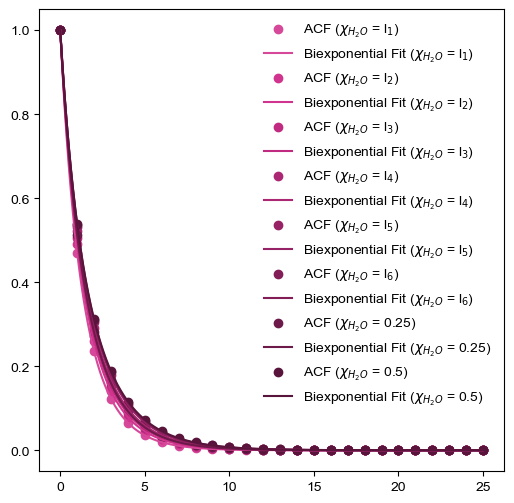

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmf_l1_ws)), acf_dmf_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmf_1)
plt.plot(fit_t_dmf_l1_ws, fit_acf_dmf_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmf_1)
plt.scatter(np.arange(len(acf_dmf_l2_ws)), acf_dmf_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmf_2)
plt.plot(fit_t_dmf_l2_ws, fit_acf_dmf_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmf_2)
plt.scatter(np.arange(len(acf_dmf_l3_ws)), acf_dmf_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmf_3)
plt.plot(fit_t_dmf_l3_ws, fit_acf_dmf_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmf_3)
plt.scatter(np.arange(len(acf_dmf_l4_ws)), acf_dmf_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmf_4)
plt.plot(fit_t_dmf_l4_ws, fit_acf_dmf_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmf_4)
plt.scatter(np.arange(len(acf_dmf_l5_ws)), acf_dmf_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmf_5)
plt.plot(fit_t_dmf_l5_ws, fit_acf_dmf_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmf_5)
plt.scatter(np.arange(len(acf_dmf_l6_ws)), acf_dmf_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmf_6)
plt.plot(fit_t_dmf_l6_ws, fit_acf_dmf_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmf_6)
plt.scatter(np.arange(len(acf_dmf_0_25_ws)), acf_dmf_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmf_7)
plt.plot(fit_t_dmf_0_25_ws, fit_acf_dmf_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmf_7)
plt.scatter(np.arange(len(acf_dmf_0_5_ws)), acf_dmf_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmf_8)
plt.plot(fit_t_dmf_0_5_ws, fit_acf_dmf_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmf_8)
plt.legend(frameon=False)

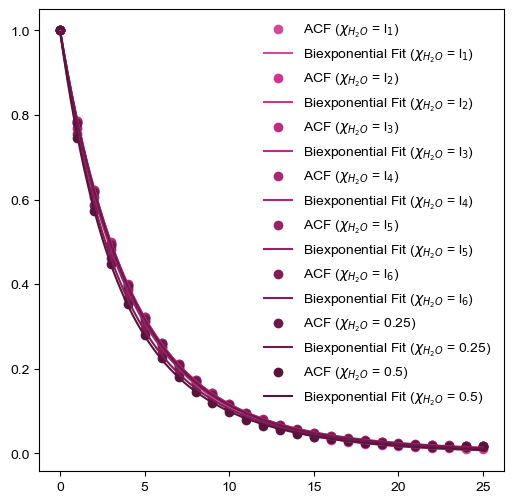

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmf_l1_ww)), acf_dmf_l1_ww, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmf_1)
plt.plot(fit_t_dmf_l1_ww, fit_acf_dmf_l1_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmf_1)
plt.scatter(np.arange(len(acf_dmf_l2_ww)), acf_dmf_l2_ww, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmf_2)
plt.plot(fit_t_dmf_l2_ww, fit_acf_dmf_l2_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmf_2)
plt.scatter(np.arange(len(acf_dmf_l3_ww)), acf_dmf_l3_ww, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmf_3)
plt.plot(fit_t_dmf_l3_ww, fit_acf_dmf_l3_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmf_3)
plt.scatter(np.arange(len(acf_dmf_l4_ww)), acf_dmf_l4_ww, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmf_4)
plt.plot(fit_t_dmf_l4_ww, fit_acf_dmf_l4_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmf_4)
plt.scatter(np.arange(len(acf_dmf_l5_ww)), acf_dmf_l5_ww, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmf_5)
plt.plot(fit_t_dmf_l5_ww, fit_acf_dmf_l5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmf_5)
plt.scatter(np.arange(len(acf_dmf_l6_ww)), acf_dmf_l6_ww, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmf_6)
plt.plot(fit_t_dmf_l6_ww, fit_acf_dmf_l6_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmf_6)
plt.scatter(np.arange(len(acf_dmf_0_25_ww)), acf_dmf_0_25_ww, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmf_7)
plt.plot(fit_t_dmf_0_25_ww, fit_acf_dmf_0_25_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmf_7)
plt.scatter(np.arange(len(acf_dmf_0_5_ww)), acf_dmf_0_5_ww, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmf_8)
plt.plot(fit_t_dmf_0_5_ww, fit_acf_dmf_0_5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmf_8)
plt.legend(frameon=False)

### ACF plot for THF-water mixtures: using 25 frames => ignore

In [34]:
df_thf_l1 = pd.read_csv('acf-data/acf_fit_thf-water_l1.csv')
df_thf_l2 = pd.read_csv('acf-data/acf_fit_thf-water_l2.csv')
df_thf_l3 = pd.read_csv('acf-data/acf_fit_thf-water_l3.csv')
df_thf_l4 = pd.read_csv('acf-data/acf_fit_thf-water_l4.csv')
df_thf_l5 = pd.read_csv('acf-data/acf_fit_thf-water_l5.csv')
df_thf_l6 = pd.read_csv('acf-data/acf_fit_thf-water_l6.csv')
df_thf_0_25 = pd.read_csv('acf-data/acf_fit_thf-water_0_25.csv')
df_thf_0_5 = pd.read_csv('acf-data/acf_fit_thf-water_0_5.csv')
df_thf_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.000000,9.999943e-01,0.000000,0.999702
1,0.438608,0.619128,0.025025,9.790911e-01,0.025025,0.987287
2,0.198361,0.401922,0.050050,9.586539e-01,0.050050,0.975057
3,0.090727,0.265933,0.075075,9.386714e-01,0.075075,0.963009
4,0.041992,0.178077,0.100100,9.191326e-01,0.100100,0.951140
...,...,...,...,...,...,...
995,NaN,NaN,24.899900,5.207616e-09,24.899900,0.000080
996,NaN,NaN,24.924925,5.109436e-09,24.924925,0.000080
997,NaN,NaN,24.949950,5.013107e-09,24.949950,0.000079
998,NaN,NaN,24.974975,4.918594e-09,24.974975,0.000078


In [35]:
thf_1 = green
thf_2 = gen_color_gradient(green)
thf_3 = gen_color_gradient(thf_2)
thf_4 = gen_color_gradient(thf_3)
thf_5 = gen_color_gradient(thf_4)
thf_6 = gen_color_gradient(thf_5)
thf_7 = gen_color_gradient(thf_6)
thf_8 = gen_color_gradient(thf_7)

In [37]:
acf_thf_l1_ws = df_thf_l1['acf_ws'].loc[df_thf_l1['acf_ws'].notna()]; acf_thf_l1_ww = df_thf_l1['acf_ww'].loc[df_thf_l1['acf_ww'].notna()]
acf_thf_l2_ws = df_thf_l2['acf_ws'].loc[df_thf_l2['acf_ws'].notna()]; acf_thf_l2_ww = df_thf_l2['acf_ww'].loc[df_thf_l2['acf_ww'].notna()]
acf_thf_l3_ws = df_thf_l3['acf_ws'].loc[df_thf_l3['acf_ws'].notna()]; acf_thf_l3_ww = df_thf_l3['acf_ww'].loc[df_thf_l3['acf_ww'].notna()]
acf_thf_l4_ws = df_thf_l4['acf_ws'].loc[df_thf_l4['acf_ws'].notna()]; acf_thf_l4_ww = df_thf_l4['acf_ww'].loc[df_thf_l4['acf_ww'].notna()]
acf_thf_l5_ws = df_thf_l5['acf_ws'].loc[df_thf_l5['acf_ws'].notna()]; acf_thf_l5_ww = df_thf_l5['acf_ww'].loc[df_thf_l5['acf_ww'].notna()]
acf_thf_l6_ws = df_thf_l6['acf_ws'].loc[df_thf_l6['acf_ws'].notna()]; acf_thf_l6_ww = df_thf_l6['acf_ww'].loc[df_thf_l6['acf_ww'].notna()]
acf_thf_0_25_ws = df_thf_0_25['acf_ws'].loc[df_thf_0_25['acf_ws'].notna()]; acf_thf_0_25_ww = df_thf_0_25['acf_ww'].loc[df_thf_0_25['acf_ww'].notna()]
acf_thf_0_5_ws = df_thf_0_5['acf_ws'].loc[df_thf_0_5['acf_ws'].notna()]; acf_thf_0_5_ww = df_thf_0_5['acf_ww'].loc[df_thf_0_5['acf_ww'].notna()]
acf_thf_0_5_ww

0     1.000000
1     0.328490
2     0.136642
3     0.064149
4     0.032598
5     0.017523
6     0.009831
7     0.005677
8     0.003349
9     0.002017
10    0.001233
11    0.000762
12    0.000480
13    0.000307
14    0.000200
15    0.000135
16    0.000094
17    0.000067
18    0.000048
19    0.000033
20    0.000022
21    0.000015
22    0.000009
23    0.000007
24    0.000005
25    0.000002
Name: acf_ww, dtype: float64

In [38]:
fit_t_thf_l1_ws = df_thf_l1['fit_t_ws'].loc[df_thf_l1['fit_t_ws'].notna()]; fit_t_thf_l1_ww = df_thf_l1['fit_t_ws'].loc[df_thf_l1['fit_t_ws'].notna()]
fit_t_thf_l2_ws = df_thf_l2['fit_t_ws'].loc[df_thf_l2['fit_t_ws'].notna()]; fit_t_thf_l2_ww = df_thf_l2['fit_t_ws'].loc[df_thf_l2['fit_t_ws'].notna()]
fit_t_thf_l3_ws = df_thf_l3['fit_t_ws'].loc[df_thf_l3['fit_t_ws'].notna()]; fit_t_thf_l3_ww = df_thf_l3['fit_t_ws'].loc[df_thf_l3['fit_t_ws'].notna()]
fit_t_thf_l4_ws = df_thf_l4['fit_t_ws'].loc[df_thf_l4['fit_t_ws'].notna()]; fit_t_thf_l4_ww = df_thf_l4['fit_t_ws'].loc[df_thf_l4['fit_t_ws'].notna()]
fit_t_thf_l5_ws = df_thf_l5['fit_t_ws'].loc[df_thf_l5['fit_t_ws'].notna()]; fit_t_thf_l5_ww = df_thf_l5['fit_t_ws'].loc[df_thf_l5['fit_t_ws'].notna()]
fit_t_thf_l6_ws = df_thf_l6['fit_t_ws'].loc[df_thf_l6['fit_t_ws'].notna()]; fit_t_thf_l6_ww = df_thf_l6['fit_t_ws'].loc[df_thf_l6['fit_t_ws'].notna()]
fit_t_thf_0_25_ws = df_thf_0_25['fit_t_ws'].loc[df_thf_0_25['fit_t_ws'].notna()]; fit_t_thf_0_25_ww = df_thf_0_25['fit_t_ws'].loc[df_thf_0_25['fit_t_ws'].notna()]
fit_t_thf_0_5_ws = df_thf_0_5['fit_t_ws'].loc[df_thf_0_5['fit_t_ws'].notna()]; fit_t_thf_0_5_ww = df_thf_0_5['fit_t_ws'].loc[df_thf_0_5['fit_t_ws'].notna()]
fit_t_thf_0_5_ww

0       0.000000
1       0.025025
2       0.050050
3       0.075075
4       0.100100
         ...    
995    24.899900
996    24.924925
997    24.949950
998    24.974975
999    25.000000
Name: fit_t_ws, Length: 1000, dtype: float64

In [39]:
fit_acf_thf_l1_ws = df_thf_l1['fit_acf_ws'].loc[df_thf_l1['fit_acf_ws'].notna()]; fit_acf_thf_l1_ww = df_thf_l1['fit_acf_ww'].loc[df_thf_l1['fit_acf_ww'].notna()]
fit_acf_thf_l2_ws = df_thf_l2['fit_acf_ws'].loc[df_thf_l2['fit_acf_ws'].notna()]; fit_acf_thf_l2_ww = df_thf_l2['fit_acf_ww'].loc[df_thf_l2['fit_acf_ww'].notna()]
fit_acf_thf_l3_ws = df_thf_l3['fit_acf_ws'].loc[df_thf_l3['fit_acf_ws'].notna()]; fit_acf_thf_l3_ww = df_thf_l3['fit_acf_ww'].loc[df_thf_l3['fit_acf_ww'].notna()]
fit_acf_thf_l4_ws = df_thf_l4['fit_acf_ws'].loc[df_thf_l4['fit_acf_ws'].notna()]; fit_acf_thf_l4_ww = df_thf_l4['fit_acf_ww'].loc[df_thf_l4['fit_acf_ww'].notna()]
fit_acf_thf_l5_ws = df_thf_l5['fit_acf_ws'].loc[df_thf_l5['fit_acf_ws'].notna()]; fit_acf_thf_l5_ww = df_thf_l5['fit_acf_ww'].loc[df_thf_l5['fit_acf_ww'].notna()]
fit_acf_thf_l6_ws = df_thf_l6['fit_acf_ws'].loc[df_thf_l6['fit_acf_ws'].notna()]; fit_acf_thf_l6_ww = df_thf_l6['fit_acf_ww'].loc[df_thf_l6['fit_acf_ww'].notna()]
fit_acf_thf_0_25_ws = df_thf_0_25['fit_acf_ws'].loc[df_thf_0_25['fit_acf_ws'].notna()]; fit_acf_thf_0_25_ww = df_thf_0_25['fit_acf_ww'].loc[df_thf_0_25['fit_acf_ww'].notna()]
fit_acf_thf_0_5_ws = df_thf_0_5['fit_acf_ws'].loc[df_thf_0_5['fit_acf_ws'].notna()]; fit_acf_thf_0_5_ww = df_thf_0_5['fit_acf_ww'].loc[df_thf_0_5['fit_acf_ww'].notna()]
fit_acf_thf_0_5_ww

0      9.999801e-01
1      9.695551e-01
2      9.401993e-01
3      9.118722e-01
4      8.845350e-01
           ...     
995    7.262865e-08
996    7.150621e-08
997    7.040111e-08
998    6.931310e-08
999    6.824189e-08
Name: fit_acf_ww, Length: 1000, dtype: float64

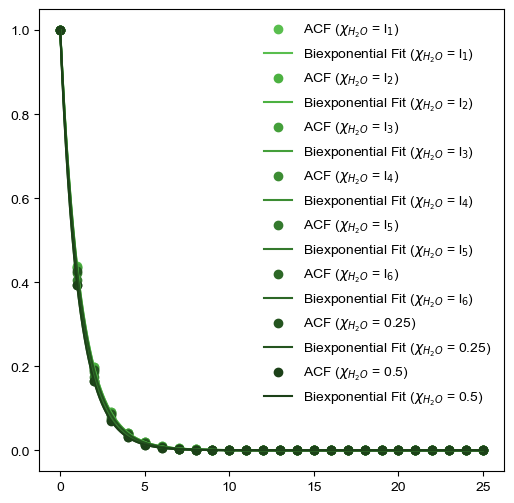

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_thf_l1_ws)), acf_thf_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=thf_1)
plt.plot(fit_t_thf_l1_ws, fit_acf_thf_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=thf_1)
plt.scatter(np.arange(len(acf_thf_l2_ws)), acf_thf_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=thf_2)
plt.plot(fit_t_thf_l2_ws, fit_acf_thf_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=thf_2)
plt.scatter(np.arange(len(acf_thf_l3_ws)), acf_thf_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=thf_3)
plt.plot(fit_t_thf_l3_ws, fit_acf_thf_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=thf_3)
plt.scatter(np.arange(len(acf_thf_l4_ws)), acf_thf_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=thf_4)
plt.plot(fit_t_thf_l4_ws, fit_acf_thf_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=thf_4)
plt.scatter(np.arange(len(acf_thf_l5_ws)), acf_thf_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=thf_5)
plt.plot(fit_t_thf_l5_ws, fit_acf_thf_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=thf_5)
plt.scatter(np.arange(len(acf_thf_l6_ws)), acf_thf_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=thf_6)
plt.plot(fit_t_thf_l6_ws, fit_acf_thf_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=thf_6)
plt.scatter(np.arange(len(acf_thf_0_25_ws)), acf_thf_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=thf_7)
plt.plot(fit_t_thf_0_25_ws, fit_acf_thf_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=thf_7)
plt.scatter(np.arange(len(acf_thf_0_5_ws)), acf_thf_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=thf_8)
plt.plot(fit_t_thf_0_5_ws, fit_acf_thf_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=thf_8)
plt.legend(frameon=False)

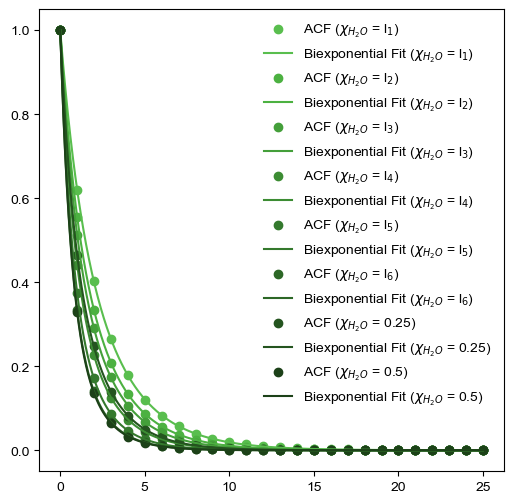

In [41]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_thf_l1_ww)), acf_thf_l1_ww, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=thf_1)
plt.plot(fit_t_thf_l1_ww, fit_acf_thf_l1_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=thf_1)
plt.scatter(np.arange(len(acf_thf_l2_ww)), acf_thf_l2_ww, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=thf_2)
plt.plot(fit_t_thf_l2_ww, fit_acf_thf_l2_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=thf_2)
plt.scatter(np.arange(len(acf_thf_l3_ww)), acf_thf_l3_ww, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=thf_3)
plt.plot(fit_t_thf_l3_ww, fit_acf_thf_l3_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=thf_3)
plt.scatter(np.arange(len(acf_thf_l4_ww)), acf_thf_l4_ww, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=thf_4)
plt.plot(fit_t_thf_l4_ww, fit_acf_thf_l4_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=thf_4)
plt.scatter(np.arange(len(acf_thf_l5_ww)), acf_thf_l5_ww, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=thf_5)
plt.plot(fit_t_thf_l5_ww, fit_acf_thf_l5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=thf_5)
plt.scatter(np.arange(len(acf_thf_l6_ww)), acf_thf_l6_ww, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=thf_6)
plt.plot(fit_t_thf_l6_ww, fit_acf_thf_l6_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=thf_6)
plt.scatter(np.arange(len(acf_thf_0_25_ww)), acf_thf_0_25_ww, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=thf_7)
plt.plot(fit_t_thf_0_25_ww, fit_acf_thf_0_25_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=thf_7)
plt.scatter(np.arange(len(acf_thf_0_5_ww)), acf_thf_0_5_ww, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=thf_8)
plt.plot(fit_t_thf_0_5_ww, fit_acf_thf_0_5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=thf_8)
plt.legend(frameon=False)

### testing new calculation for DMSO-water mixture: ignore

In [49]:
# df_dmso_l1 = pd.read_csv('acf-data/acf_fit_dmso-water_l1_test.csv')
df_dmso_l1 = pd.read_csv('acf-data/acf_fit_dmso-water_l1_nn.csv')
df_dmso_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.0000,1.000026,0.0000,9.992770e-01
1,0.896822,0.754747,0.1001,0.989043,0.1001,9.714730e-01
2,0.805452,0.577796,0.2002,0.978216,0.2002,9.445258e-01
3,0.723604,0.444083,0.3003,0.967540,0.3003,9.184057e-01
4,0.650285,0.343451,0.4004,0.957010,0.4004,8.930842e-01
...,...,...,...,...,...,...
995,NaN,NaN,99.5996,0.000025,99.5996,4.978155e-11
996,NaN,NaN,99.6997,0.000024,99.6997,4.861924e-11
997,NaN,NaN,99.7998,0.000024,99.7998,4.748408e-11
998,NaN,NaN,99.8999,0.000024,99.8999,4.637541e-11


In [50]:
acf_dmso_l1_ws = df_dmso_l1['acf_ws'].loc[df_dmso_l1['acf_ws'].notna()]; acf_dmso_l1_ww = df_dmso_l1['acf_ww'].loc[df_dmso_l1['acf_ww'].notna()]

In [51]:
fit_t_dmso_l1_ws = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]; fit_t_dmso_l1_ww = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]

In [52]:
fit_acf_dmso_l1_ws = df_dmso_l1['fit_acf_ws'].loc[df_dmso_l1['fit_acf_ws'].notna()]; fit_acf_dmso_l1_ww = df_dmso_l1['fit_acf_ww'].loc[df_dmso_l1['fit_acf_ww'].notna()]

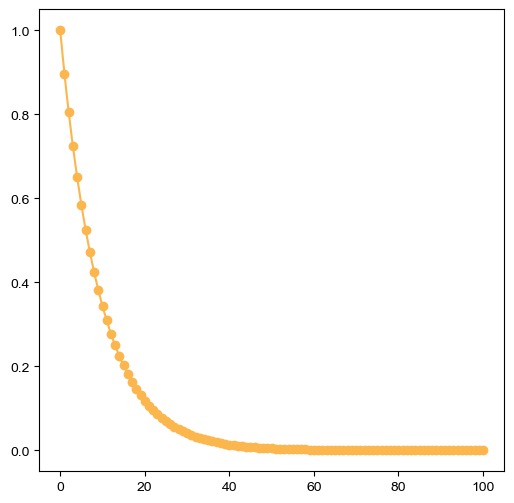

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmso_l1_ws)), acf_dmso_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.plot(fit_t_dmso_l1_ws, fit_acf_dmso_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)

### ACF plot for DMSO-water mixtures: using 100 frames => finally used in revision

In [54]:
df_dmso_l1 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_l1.csv')
df_dmso_l2 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_l2.csv')
df_dmso_l3 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_l3.csv')
df_dmso_l4 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_l4.csv')
df_dmso_l5 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_l5.csv')
df_dmso_l6 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_l6.csv')
df_dmso_0_25 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_0_25.csv')
df_dmso_0_5 = pd.read_csv('acf-data_tau_frame_100/acf_fit_dmso-water_0_5.csv')
df_dmso_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.0000,1.000026,0.0000,9.992770e-01
1,0.896822,0.754747,0.1001,0.989043,0.1001,9.714730e-01
2,0.805452,0.577796,0.2002,0.978216,0.2002,9.445258e-01
3,0.723604,0.444083,0.3003,0.967540,0.3003,9.184057e-01
4,0.650285,0.343451,0.4004,0.957010,0.4004,8.930842e-01
...,...,...,...,...,...,...
995,NaN,NaN,99.5996,0.000025,99.5996,4.978155e-11
996,NaN,NaN,99.6997,0.000024,99.6997,4.861924e-11
997,NaN,NaN,99.7998,0.000024,99.7998,4.748408e-11
998,NaN,NaN,99.8999,0.000024,99.8999,4.637541e-11


In [55]:
dmso_1 = orange
dmso_2 = gen_color_gradient(orange)
dmso_3 = gen_color_gradient(dmso_2)
dmso_4 = gen_color_gradient(dmso_3)
dmso_5 = gen_color_gradient(dmso_4)
dmso_6 = gen_color_gradient(dmso_5)
dmso_7 = gen_color_gradient(dmso_6)
dmso_8 = gen_color_gradient(dmso_7)

In [56]:
acf_dmso_l1_ws = df_dmso_l1['acf_ws'].loc[df_dmso_l1['acf_ws'].notna()]; acf_dmso_l1_ww = df_dmso_l1['acf_ww'].loc[df_dmso_l1['acf_ww'].notna()]
acf_dmso_l2_ws = df_dmso_l2['acf_ws'].loc[df_dmso_l2['acf_ws'].notna()]; acf_dmso_l2_ww = df_dmso_l2['acf_ww'].loc[df_dmso_l2['acf_ww'].notna()]
acf_dmso_l3_ws = df_dmso_l3['acf_ws'].loc[df_dmso_l3['acf_ws'].notna()]; acf_dmso_l3_ww = df_dmso_l3['acf_ww'].loc[df_dmso_l3['acf_ww'].notna()]
acf_dmso_l4_ws = df_dmso_l4['acf_ws'].loc[df_dmso_l4['acf_ws'].notna()]; acf_dmso_l4_ww = df_dmso_l4['acf_ww'].loc[df_dmso_l4['acf_ww'].notna()]
acf_dmso_l5_ws = df_dmso_l5['acf_ws'].loc[df_dmso_l5['acf_ws'].notna()]; acf_dmso_l5_ww = df_dmso_l5['acf_ww'].loc[df_dmso_l5['acf_ww'].notna()]
acf_dmso_l6_ws = df_dmso_l6['acf_ws'].loc[df_dmso_l6['acf_ws'].notna()]; acf_dmso_l6_ww = df_dmso_l6['acf_ww'].loc[df_dmso_l6['acf_ww'].notna()]
acf_dmso_0_25_ws = df_dmso_0_25['acf_ws'].loc[df_dmso_0_25['acf_ws'].notna()]; acf_dmso_0_25_ww = df_dmso_0_25['acf_ww'].loc[df_dmso_0_25['acf_ww'].notna()]
acf_dmso_0_5_ws = df_dmso_0_5['acf_ws'].loc[df_dmso_0_5['acf_ws'].notna()]; acf_dmso_0_5_ww = df_dmso_0_5['acf_ww'].loc[df_dmso_0_5['acf_ww'].notna()]
acf_dmso_0_5_ww

0      1.000000
1      0.755754
2      0.588479
3      0.463430
4      0.367325
         ...   
96     0.000000
97     0.000000
98     0.000000
99     0.000000
100    0.000000
Name: acf_ww, Length: 101, dtype: float64

In [57]:
fit_t_dmso_l1_ws = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]; fit_t_dmso_l1_ww = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]
fit_t_dmso_l2_ws = df_dmso_l2['fit_t_ws'].loc[df_dmso_l2['fit_t_ws'].notna()]; fit_t_dmso_l2_ww = df_dmso_l2['fit_t_ws'].loc[df_dmso_l2['fit_t_ws'].notna()]
fit_t_dmso_l3_ws = df_dmso_l3['fit_t_ws'].loc[df_dmso_l3['fit_t_ws'].notna()]; fit_t_dmso_l3_ww = df_dmso_l3['fit_t_ws'].loc[df_dmso_l3['fit_t_ws'].notna()]
fit_t_dmso_l4_ws = df_dmso_l4['fit_t_ws'].loc[df_dmso_l4['fit_t_ws'].notna()]; fit_t_dmso_l4_ww = df_dmso_l4['fit_t_ws'].loc[df_dmso_l4['fit_t_ws'].notna()]
fit_t_dmso_l5_ws = df_dmso_l5['fit_t_ws'].loc[df_dmso_l5['fit_t_ws'].notna()]; fit_t_dmso_l5_ww = df_dmso_l5['fit_t_ws'].loc[df_dmso_l5['fit_t_ws'].notna()]
fit_t_dmso_l6_ws = df_dmso_l6['fit_t_ws'].loc[df_dmso_l6['fit_t_ws'].notna()]; fit_t_dmso_l6_ww = df_dmso_l6['fit_t_ws'].loc[df_dmso_l6['fit_t_ws'].notna()]
fit_t_dmso_0_25_ws = df_dmso_0_25['fit_t_ws'].loc[df_dmso_0_25['fit_t_ws'].notna()]; fit_t_dmso_0_25_ww = df_dmso_0_25['fit_t_ws'].loc[df_dmso_0_25['fit_t_ws'].notna()]
fit_t_dmso_0_5_ws = df_dmso_0_5['fit_t_ws'].loc[df_dmso_0_5['fit_t_ws'].notna()]; fit_t_dmso_0_5_ww = df_dmso_0_5['fit_t_ws'].loc[df_dmso_0_5['fit_t_ws'].notna()]
fit_t_dmso_0_5_ww

0        0.0000
1        0.1001
2        0.2002
3        0.3003
4        0.4004
         ...   
995     99.5996
996     99.6997
997     99.7998
998     99.8999
999    100.0000
Name: fit_t_ws, Length: 1000, dtype: float64

In [58]:
fit_acf_dmso_l1_ws = df_dmso_l1['fit_acf_ws'].loc[df_dmso_l1['fit_acf_ws'].notna()]; fit_acf_dmso_l1_ww = df_dmso_l1['fit_acf_ww'].loc[df_dmso_l1['fit_acf_ww'].notna()]
fit_acf_dmso_l2_ws = df_dmso_l2['fit_acf_ws'].loc[df_dmso_l2['fit_acf_ws'].notna()]; fit_acf_dmso_l2_ww = df_dmso_l2['fit_acf_ww'].loc[df_dmso_l2['fit_acf_ww'].notna()]
fit_acf_dmso_l3_ws = df_dmso_l3['fit_acf_ws'].loc[df_dmso_l3['fit_acf_ws'].notna()]; fit_acf_dmso_l3_ww = df_dmso_l3['fit_acf_ww'].loc[df_dmso_l3['fit_acf_ww'].notna()]
fit_acf_dmso_l4_ws = df_dmso_l4['fit_acf_ws'].loc[df_dmso_l4['fit_acf_ws'].notna()]; fit_acf_dmso_l4_ww = df_dmso_l4['fit_acf_ww'].loc[df_dmso_l4['fit_acf_ww'].notna()]
fit_acf_dmso_l5_ws = df_dmso_l5['fit_acf_ws'].loc[df_dmso_l5['fit_acf_ws'].notna()]; fit_acf_dmso_l5_ww = df_dmso_l5['fit_acf_ww'].loc[df_dmso_l5['fit_acf_ww'].notna()]
fit_acf_dmso_l6_ws = df_dmso_l6['fit_acf_ws'].loc[df_dmso_l6['fit_acf_ws'].notna()]; fit_acf_dmso_l6_ww = df_dmso_l6['fit_acf_ww'].loc[df_dmso_l6['fit_acf_ww'].notna()]
fit_acf_dmso_0_25_ws = df_dmso_0_25['fit_acf_ws'].loc[df_dmso_0_25['fit_acf_ws'].notna()]; fit_acf_dmso_0_25_ww = df_dmso_0_25['fit_acf_ww'].loc[df_dmso_0_25['fit_acf_ww'].notna()]
fit_acf_dmso_0_5_ws = df_dmso_0_5['fit_acf_ws'].loc[df_dmso_0_5['fit_acf_ws'].notna()]; fit_acf_dmso_0_5_ww = df_dmso_0_5['fit_acf_ww'].loc[df_dmso_0_5['fit_acf_ww'].notna()]
fit_acf_dmso_0_5_ww

0      9.994291e-01
1      9.709001e-01
2      9.434763e-01
3      9.170997e-01
4      8.917162e-01
           ...     
995    3.779547e-10
996    3.698626e-10
997    3.619438e-10
998    3.541945e-10
999    3.466112e-10
Name: fit_acf_ww, Length: 1000, dtype: float64

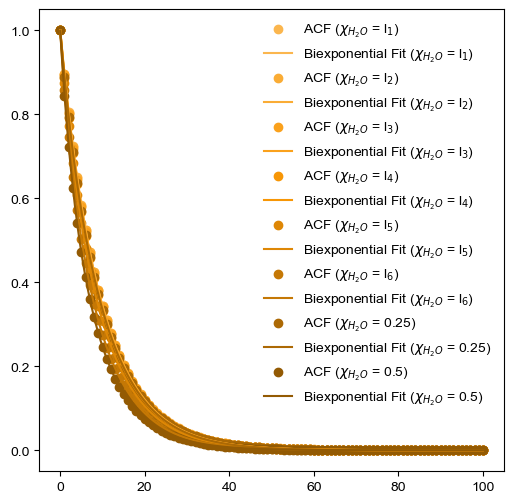

In [59]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmso_l1_ws)), acf_dmso_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.plot(fit_t_dmso_l1_ws, fit_acf_dmso_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.scatter(np.arange(len(acf_dmso_l2_ws)), acf_dmso_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.plot(fit_t_dmso_l2_ws, fit_acf_dmso_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.scatter(np.arange(len(acf_dmso_l3_ws)), acf_dmso_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.plot(fit_t_dmso_l3_ws, fit_acf_dmso_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.scatter(np.arange(len(acf_dmso_l4_ws)), acf_dmso_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.plot(fit_t_dmso_l4_ws, fit_acf_dmso_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.scatter(np.arange(len(acf_dmso_l5_ws)), acf_dmso_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.plot(fit_t_dmso_l5_ws, fit_acf_dmso_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.scatter(np.arange(len(acf_dmso_l6_ws)), acf_dmso_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.plot(fit_t_dmso_l6_ws, fit_acf_dmso_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.scatter(np.arange(len(acf_dmso_0_25_ws)), acf_dmso_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.plot(fit_t_dmso_0_25_ws, fit_acf_dmso_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.scatter(np.arange(len(acf_dmso_0_5_ws)), acf_dmso_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.plot(fit_t_dmso_0_5_ws, fit_acf_dmso_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.legend(frameon=False)

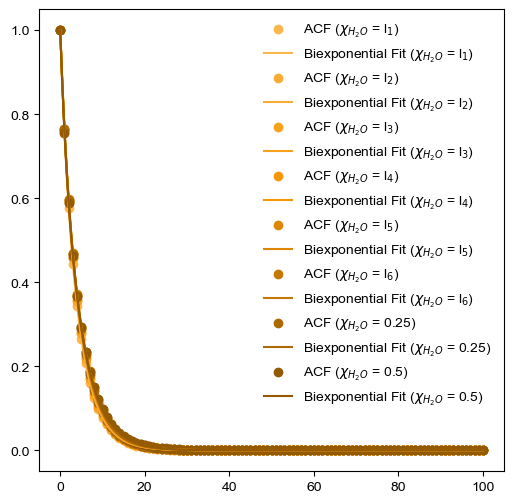

In [60]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmso_l1_ww)), acf_dmso_l1_ww, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.plot(fit_t_dmso_l1_ww, fit_acf_dmso_l1_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.scatter(np.arange(len(acf_dmso_l2_ww)), acf_dmso_l2_ww, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.plot(fit_t_dmso_l2_ww, fit_acf_dmso_l2_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.scatter(np.arange(len(acf_dmso_l3_ww)), acf_dmso_l3_ww, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.plot(fit_t_dmso_l3_ww, fit_acf_dmso_l3_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.scatter(np.arange(len(acf_dmso_l4_ww)), acf_dmso_l4_ww, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.plot(fit_t_dmso_l4_ww, fit_acf_dmso_l4_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.scatter(np.arange(len(acf_dmso_l5_ww)), acf_dmso_l5_ww, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.plot(fit_t_dmso_l5_ww, fit_acf_dmso_l5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.scatter(np.arange(len(acf_dmso_l6_ww)), acf_dmso_l6_ww, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.plot(fit_t_dmso_l6_ww, fit_acf_dmso_l6_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.scatter(np.arange(len(acf_dmso_0_25_ww)), acf_dmso_0_25_ww, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.plot(fit_t_dmso_0_25_ww, fit_acf_dmso_0_25_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.scatter(np.arange(len(acf_dmso_0_5_ww)), acf_dmso_0_5_ww, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.plot(fit_t_dmso_0_5_ww, fit_acf_dmso_0_5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.legend(frameon=False)

### ACF plot for ACN-water mixtures: using tau_frame = 100 & dt = 1 => ignore

In [5]:
df_acn_l1 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_l1.csv')
df_acn_l2 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_l2.csv')
df_acn_l3 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_l3.csv')
df_acn_l4 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_l4.csv')
df_acn_l5 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_l5.csv')
df_acn_l6 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_l6.csv')
df_acn_0_25 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_0_25.csv')
df_acn_0_5 = pd.read_csv('acf-data_tau_frame_100/acf_fit_acn-water_0_5.csv')
df_acn_l1

,acf_ws,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.000000,1.000000,0.0000,1.000000e+00,0.0000,9.999990e-01
1,0.019611,0.415193,0.1001,6.214617e-01,0.1001,9.100696e-01
2,0.000429,0.184952,0.2002,4.182280e-01,0.2002,8.297459e-01
3,0.000008,0.083617,0.3003,2.847155e-01,0.3003,7.577534e-01
4,0.000000,0.038172,0.4004,1.941310e-01,0.4004,6.930208e-01
...,...,...,...,...,...,...
995,NaN,NaN,99.5996,3.765786e-166,99.5996,1.062232e-34
996,NaN,NaN,99.6997,2.568311e-166,99.6997,9.820443e-35
997,NaN,NaN,99.7998,1.751618e-166,99.7998,9.079098e-35
998,NaN,NaN,99.8999,1.194624e-166,99.8999,8.393718e-35


In [8]:
acn_1 = blue
acn_2 = gen_color_gradient(blue)
acn_3 = gen_color_gradient(acn_2)
acn_4 = gen_color_gradient(acn_3)
acn_5 = gen_color_gradient(acn_4)
acn_6 = gen_color_gradient(acn_5)
acn_7 = gen_color_gradient(acn_6)
acn_8 = gen_color_gradient(acn_7)

In [9]:
acf_acn_l1_ws = df_acn_l1['acf_ws'].loc[df_acn_l1['acf_ws'].notna()]; acf_acn_l1_ww = df_acn_l1['acf_ww'].loc[df_acn_l1['acf_ww'].notna()]
acf_acn_l2_ws = df_acn_l2['acf_ws'].loc[df_acn_l2['acf_ws'].notna()]; acf_acn_l2_ww = df_acn_l2['acf_ww'].loc[df_acn_l2['acf_ww'].notna()]
acf_acn_l3_ws = df_acn_l3['acf_ws'].loc[df_acn_l3['acf_ws'].notna()]; acf_acn_l3_ww = df_acn_l3['acf_ww'].loc[df_acn_l3['acf_ww'].notna()]
acf_acn_l4_ws = df_acn_l4['acf_ws'].loc[df_acn_l4['acf_ws'].notna()]; acf_acn_l4_ww = df_acn_l4['acf_ww'].loc[df_acn_l4['acf_ww'].notna()]
acf_acn_l5_ws = df_acn_l5['acf_ws'].loc[df_acn_l5['acf_ws'].notna()]; acf_acn_l5_ww = df_acn_l5['acf_ww'].loc[df_acn_l5['acf_ww'].notna()]
acf_acn_l6_ws = df_acn_l6['acf_ws'].loc[df_acn_l6['acf_ws'].notna()]; acf_acn_l6_ww = df_acn_l6['acf_ww'].loc[df_acn_l6['acf_ww'].notna()]
acf_acn_0_25_ws = df_acn_0_25['acf_ws'].loc[df_acn_0_25['acf_ws'].notna()]; acf_acn_0_25_ww = df_acn_0_25['acf_ww'].loc[df_acn_0_25['acf_ww'].notna()]
acf_acn_0_5_ws = df_acn_0_5['acf_ws'].loc[df_acn_0_5['acf_ws'].notna()]; acf_acn_0_5_ww = df_acn_0_5['acf_ww'].loc[df_acn_0_5['acf_ww'].notna()]
acf_acn_0_25_ws

0      1.000000
1      0.018402
2      0.000370
3      0.000009
4      0.000000
         ...   
96     0.000000
97     0.000000
98     0.000000
99     0.000000
100    0.000000
Name: acf_ws, Length: 101, dtype: float64

In [10]:
fit_t_acn_l1_ws = df_acn_l1['fit_t_ws'].loc[df_acn_l1['fit_t_ws'].notna()]; fit_t_acn_l1_ww = df_acn_l1['fit_t_ws'].loc[df_acn_l1['fit_t_ws'].notna()]
fit_t_acn_l2_ws = df_acn_l2['fit_t_ws'].loc[df_acn_l2['fit_t_ws'].notna()]; fit_t_acn_l2_ww = df_acn_l2['fit_t_ws'].loc[df_acn_l2['fit_t_ws'].notna()]
fit_t_acn_l3_ws = df_acn_l3['fit_t_ws'].loc[df_acn_l3['fit_t_ws'].notna()]; fit_t_acn_l3_ww = df_acn_l3['fit_t_ws'].loc[df_acn_l3['fit_t_ws'].notna()]
fit_t_acn_l4_ws = df_acn_l4['fit_t_ws'].loc[df_acn_l4['fit_t_ws'].notna()]; fit_t_acn_l4_ww = df_acn_l4['fit_t_ws'].loc[df_acn_l4['fit_t_ws'].notna()]
fit_t_acn_l5_ws = df_acn_l5['fit_t_ws'].loc[df_acn_l5['fit_t_ws'].notna()]; fit_t_acn_l5_ww = df_acn_l5['fit_t_ws'].loc[df_acn_l5['fit_t_ws'].notna()]
fit_t_acn_l6_ws = df_acn_l6['fit_t_ws'].loc[df_acn_l6['fit_t_ws'].notna()]; fit_t_acn_l6_ww = df_acn_l6['fit_t_ws'].loc[df_acn_l6['fit_t_ws'].notna()]
fit_t_acn_0_25_ws = df_acn_0_25['fit_t_ws'].loc[df_acn_0_25['fit_t_ws'].notna()]; fit_t_acn_0_25_ww = df_acn_0_25['fit_t_ws'].loc[df_acn_0_25['fit_t_ws'].notna()]
fit_t_acn_0_5_ws = df_acn_0_5['fit_t_ws'].loc[df_acn_0_5['fit_t_ws'].notna()]; fit_t_acn_0_5_ww = df_acn_0_5['fit_t_ws'].loc[df_acn_0_5['fit_t_ws'].notna()]
fit_t_acn_0_5_ww

0        0.0000
1        0.1001
2        0.2002
3        0.3003
4        0.4004
         ...   
995     99.5996
996     99.6997
997     99.7998
998     99.8999
999    100.0000
Name: fit_t_ws, Length: 1000, dtype: float64

In [11]:
fit_acf_acn_l1_ws = df_acn_l1['fit_acf_ws'].loc[df_acn_l1['fit_acf_ws'].notna()]; fit_acf_acn_l1_ww = df_acn_l1['fit_acf_ww'].loc[df_acn_l1['fit_acf_ww'].notna()]  
fit_acf_acn_l2_ws = df_acn_l2['fit_acf_ws'].loc[df_acn_l2['fit_acf_ws'].notna()]; fit_acf_acn_l2_ww = df_acn_l2['fit_acf_ww'].loc[df_acn_l2['fit_acf_ww'].notna()]
fit_acf_acn_l3_ws = df_acn_l3['fit_acf_ws'].loc[df_acn_l3['fit_acf_ws'].notna()]; fit_acf_acn_l3_ww = df_acn_l3['fit_acf_ww'].loc[df_acn_l3['fit_acf_ww'].notna()]
fit_acf_acn_l4_ws = df_acn_l4['fit_acf_ws'].loc[df_acn_l4['fit_acf_ws'].notna()]; fit_acf_acn_l4_ww = df_acn_l4['fit_acf_ww'].loc[df_acn_l4['fit_acf_ww'].notna()]
fit_acf_acn_l5_ws = df_acn_l5['fit_acf_ws'].loc[df_acn_l5['fit_acf_ws'].notna()]; fit_acf_acn_l5_ww = df_acn_l5['fit_acf_ww'].loc[df_acn_l5['fit_acf_ww'].notna()]
fit_acf_acn_l6_ws = df_acn_l6['fit_acf_ws'].loc[df_acn_l6['fit_acf_ws'].notna()]; fit_acf_acn_l6_ww = df_acn_l6['fit_acf_ww'].loc[df_acn_l6['fit_acf_ww'].notna()]
fit_acf_acn_0_25_ws = df_acn_0_25['fit_acf_ws'].loc[df_acn_0_25['fit_acf_ws'].notna()]; fit_acf_acn_0_25_ww = df_acn_0_25['fit_acf_ww'].loc[df_acn_0_25['fit_acf_ww'].notna()]
fit_acf_acn_0_5_ws = df_acn_0_5['fit_acf_ws'].loc[df_acn_0_5['fit_acf_ws'].notna()]; fit_acf_acn_0_5_ww = df_acn_0_5['fit_acf_ww'].loc[df_acn_0_5['fit_acf_ww'].notna()]
fit_acf_acn_0_5_ww

0      9.999999e-01
1      8.106699e-01
2      6.589799e-01
3      5.372069e-01
4      4.392432e-01
           ...     
995    1.400487e-55
996    1.235197e-55
997    1.089415e-55
998    9.608393e-56
999    8.474381e-56
Name: fit_acf_ww, Length: 1000, dtype: float64

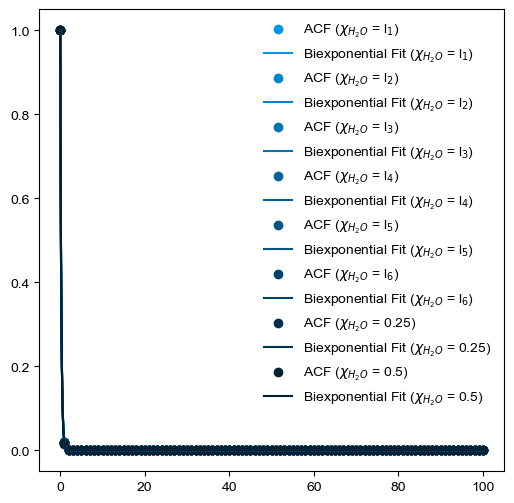

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_acn_l1_ws)), acf_acn_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.plot(fit_t_acn_l1_ws, fit_acf_acn_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.scatter(np.arange(len(acf_acn_l2_ws)), acf_acn_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.plot(fit_t_acn_l2_ws, fit_acf_acn_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.scatter(np.arange(len(acf_acn_l3_ws)), acf_acn_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.plot(fit_t_acn_l3_ws, fit_acf_acn_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.scatter(np.arange(len(acf_acn_l4_ws)), acf_acn_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.plot(fit_t_acn_l4_ws, fit_acf_acn_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.scatter(np.arange(len(acf_acn_l5_ws)), acf_acn_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.plot(fit_t_acn_l5_ws, fit_acf_acn_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.scatter(np.arange(len(acf_acn_l6_ws)), acf_acn_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.plot(fit_t_acn_l6_ws, fit_acf_acn_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.scatter(np.arange(len(acf_acn_0_25_ws)), acf_acn_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.plot(fit_t_acn_0_25_ws, fit_acf_acn_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.scatter(np.arange(len(acf_acn_0_5_ws)), acf_acn_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)
plt.plot(fit_t_acn_0_5_ws, fit_acf_acn_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)

plt.legend(frameon=False)

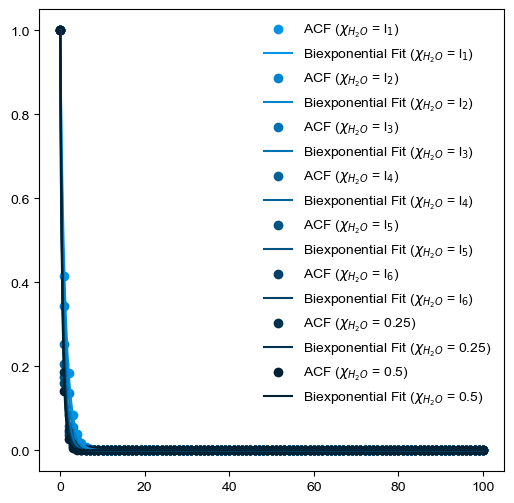

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_acn_l1_ww)), acf_acn_l1_ww, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.plot(fit_t_acn_l1_ww, fit_acf_acn_l1_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=acn_1)
plt.scatter(np.arange(len(acf_acn_l2_ww)), acf_acn_l2_ww, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.plot(fit_t_acn_l2_ww, fit_acf_acn_l2_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=acn_2)
plt.scatter(np.arange(len(acf_acn_l3_ww)), acf_acn_l3_ww, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.plot(fit_t_acn_l3_ww, fit_acf_acn_l3_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=acn_3)
plt.scatter(np.arange(len(acf_acn_l4_ww)), acf_acn_l4_ww, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.plot(fit_t_acn_l4_ww, fit_acf_acn_l4_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=acn_4)
plt.scatter(np.arange(len(acf_acn_l5_ww)), acf_acn_l5_ww, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.plot(fit_t_acn_l5_ww, fit_acf_acn_l5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=acn_5)
plt.scatter(np.arange(len(acf_acn_l6_ww)), acf_acn_l6_ww, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.plot(fit_t_acn_l6_ww, fit_acf_acn_l6_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=acn_6)
plt.scatter(np.arange(len(acf_acn_0_25_ww)), acf_acn_0_25_ww, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.plot(fit_t_acn_0_25_ww, fit_acf_acn_0_25_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=acn_7)
plt.scatter(np.arange(len(acf_acn_0_5_ww)), acf_acn_0_5_ww, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)
plt.plot(fit_t_acn_0_5_ww, fit_acf_acn_0_5_ww, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=acn_8)
plt.legend(frameon=False)

### ACF plot for DMF-water mixtures: using tau_frame = 100 & dt = 1 => ignore

### ACF plot for THF-water mixtures: using tau_frame = 100 & dt = 1 => ignore

### ACF plot for ACN-water mixtures: using tau_frame = 100 & dt = 10 => finally used

### ACF plot for DMSO-water mixtures: using tau_frame = 100 & dt = 10 => finally used

In [35]:
df_dmso_l1 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_l1.csv')
df_dmso_l2 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_l2.csv')
df_dmso_l3 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_l3.csv')
df_dmso_l4 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_l4.csv')
df_dmso_l5 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_l5.csv')
df_dmso_l6 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_l6.csv')
df_dmso_0_25 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_0_25.csv')
df_dmso_0_5 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmso-water_0_5.csv')
df_dmso_l1

,tau_time_ws,acf_ws,tau_time_ww,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,10.0,1.000000,10.0,1.000000,10.0000,1.000026,10.0000,9.992770e-01
1,11.0,0.896822,11.0,0.754747,10.1001,0.989043,10.1001,9.714730e-01
2,12.0,0.805452,12.0,0.577796,10.2002,0.978216,10.2002,9.445258e-01
3,13.0,0.723604,13.0,0.444083,10.3003,0.967540,10.3003,9.184057e-01
4,14.0,0.650285,14.0,0.343451,10.4004,0.957010,10.4004,8.930842e-01
...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,109.5996,0.000025,109.5996,4.978409e-11
996,NaN,NaN,NaN,NaN,109.6997,0.000024,109.6997,4.862173e-11
997,NaN,NaN,NaN,NaN,109.7998,0.000024,109.7998,4.748650e-11
998,NaN,NaN,NaN,NaN,109.8999,0.000024,109.8999,4.637779e-11


In [36]:
dmso_1 = orange
dmso_2 = gen_color_gradient(orange)
dmso_3 = gen_color_gradient(dmso_2)
dmso_4 = gen_color_gradient(dmso_3)
dmso_5 = gen_color_gradient(dmso_4)
dmso_6 = gen_color_gradient(dmso_5)
dmso_7 = gen_color_gradient(dmso_6)
dmso_8 = gen_color_gradient(dmso_7)

In [42]:
t_acf_dmso_l1_ws = df_dmso_l1['tau_time_ws'].loc[df_dmso_l1['tau_time_ws'].notna()]; t_acf_dmso_l1_ww = df_dmso_l1['tau_time_ww'].loc[df_dmso_l1['tau_time_ww'].notna()]
t_acf_dmso_l2_ws = df_dmso_l2['tau_time_ws'].loc[df_dmso_l2['tau_time_ws'].notna()]; t_acf_dmso_l2_ww = df_dmso_l2['tau_time_ww'].loc[df_dmso_l2['tau_time_ww'].notna()]
t_acf_dmso_l3_ws = df_dmso_l3['tau_time_ws'].loc[df_dmso_l3['tau_time_ws'].notna()]; t_acf_dmso_l3_ww = df_dmso_l3['tau_time_ww'].loc[df_dmso_l3['tau_time_ww'].notna()]
t_acf_dmso_l4_ws = df_dmso_l4['tau_time_ws'].loc[df_dmso_l4['tau_time_ws'].notna()]; t_acf_dmso_l4_ww = df_dmso_l4['tau_time_ww'].loc[df_dmso_l4['tau_time_ww'].notna()]
t_acf_dmso_l5_ws = df_dmso_l5['tau_time_ws'].loc[df_dmso_l5['tau_time_ws'].notna()]; t_acf_dmso_l5_ww = df_dmso_l5['tau_time_ww'].loc[df_dmso_l5['tau_time_ww'].notna()]
t_acf_dmso_l6_ws = df_dmso_l6['tau_time_ws'].loc[df_dmso_l6['tau_time_ws'].notna()]; t_acf_dmso_l6_ww = df_dmso_l6['tau_time_ww'].loc[df_dmso_l6['tau_time_ww'].notna()]
t_acf_dmso_0_25_ws = df_dmso_0_25['tau_time_ws'].loc[df_dmso_0_25['tau_time_ws'].notna()]; t_acf_dmso_0_25_ww = df_dmso_0_25['tau_time_ww'].loc[df_dmso_0_25['tau_time_ww'].notna()]
t_acf_dmso_0_5_ws = df_dmso_0_5['tau_time_ws'].loc[df_dmso_0_5['tau_time_ws'].notna()]; t_acf_dmso_0_5_ww = df_dmso_0_5['tau_time_ww'].loc[df_dmso_0_5['tau_time_ww'].notna()]

In [37]:
acf_dmso_l1_ws = df_dmso_l1['acf_ws'].loc[df_dmso_l1['acf_ws'].notna()]; acf_dmso_l1_ww = df_dmso_l1['acf_ww'].loc[df_dmso_l1['acf_ww'].notna()]
acf_dmso_l2_ws = df_dmso_l2['acf_ws'].loc[df_dmso_l2['acf_ws'].notna()]; acf_dmso_l2_ww = df_dmso_l2['acf_ww'].loc[df_dmso_l2['acf_ww'].notna()]
acf_dmso_l3_ws = df_dmso_l3['acf_ws'].loc[df_dmso_l3['acf_ws'].notna()]; acf_dmso_l3_ww = df_dmso_l3['acf_ww'].loc[df_dmso_l3['acf_ww'].notna()]
acf_dmso_l4_ws = df_dmso_l4['acf_ws'].loc[df_dmso_l4['acf_ws'].notna()]; acf_dmso_l4_ww = df_dmso_l4['acf_ww'].loc[df_dmso_l4['acf_ww'].notna()]
acf_dmso_l5_ws = df_dmso_l5['acf_ws'].loc[df_dmso_l5['acf_ws'].notna()]; acf_dmso_l5_ww = df_dmso_l5['acf_ww'].loc[df_dmso_l5['acf_ww'].notna()]
acf_dmso_l6_ws = df_dmso_l6['acf_ws'].loc[df_dmso_l6['acf_ws'].notna()]; acf_dmso_l6_ww = df_dmso_l6['acf_ww'].loc[df_dmso_l6['acf_ww'].notna()]
acf_dmso_0_25_ws = df_dmso_0_25['acf_ws'].loc[df_dmso_0_25['acf_ws'].notna()]; acf_dmso_0_25_ww = df_dmso_0_25['acf_ww'].loc[df_dmso_0_25['acf_ww'].notna()]
acf_dmso_0_5_ws = df_dmso_0_5['acf_ws'].loc[df_dmso_0_5['acf_ws'].notna()]; acf_dmso_0_5_ww = df_dmso_0_5['acf_ww'].loc[df_dmso_0_5['acf_ww'].notna()]
acf_dmso_0_5_ww

0      1.000000
1      0.755754
2      0.588479
3      0.463430
4      0.367325
         ...   
96     0.000000
97     0.000000
98     0.000000
99     0.000000
100    0.000000
Name: acf_ww, Length: 101, dtype: float64

In [38]:
fit_t_dmso_l1_ws = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]; fit_t_dmso_l1_ww = df_dmso_l1['fit_t_ws'].loc[df_dmso_l1['fit_t_ws'].notna()]
fit_t_dmso_l2_ws = df_dmso_l2['fit_t_ws'].loc[df_dmso_l2['fit_t_ws'].notna()]; fit_t_dmso_l2_ww = df_dmso_l2['fit_t_ws'].loc[df_dmso_l2['fit_t_ws'].notna()]
fit_t_dmso_l3_ws = df_dmso_l3['fit_t_ws'].loc[df_dmso_l3['fit_t_ws'].notna()]; fit_t_dmso_l3_ww = df_dmso_l3['fit_t_ws'].loc[df_dmso_l3['fit_t_ws'].notna()]
fit_t_dmso_l4_ws = df_dmso_l4['fit_t_ws'].loc[df_dmso_l4['fit_t_ws'].notna()]; fit_t_dmso_l4_ww = df_dmso_l4['fit_t_ws'].loc[df_dmso_l4['fit_t_ws'].notna()]
fit_t_dmso_l5_ws = df_dmso_l5['fit_t_ws'].loc[df_dmso_l5['fit_t_ws'].notna()]; fit_t_dmso_l5_ww = df_dmso_l5['fit_t_ws'].loc[df_dmso_l5['fit_t_ws'].notna()]
fit_t_dmso_l6_ws = df_dmso_l6['fit_t_ws'].loc[df_dmso_l6['fit_t_ws'].notna()]; fit_t_dmso_l6_ww = df_dmso_l6['fit_t_ws'].loc[df_dmso_l6['fit_t_ws'].notna()]
fit_t_dmso_0_25_ws = df_dmso_0_25['fit_t_ws'].loc[df_dmso_0_25['fit_t_ws'].notna()]; fit_t_dmso_0_25_ww = df_dmso_0_25['fit_t_ws'].loc[df_dmso_0_25['fit_t_ws'].notna()]
fit_t_dmso_0_5_ws = df_dmso_0_5['fit_t_ws'].loc[df_dmso_0_5['fit_t_ws'].notna()]; fit_t_dmso_0_5_ww = df_dmso_0_5['fit_t_ws'].loc[df_dmso_0_5['fit_t_ws'].notna()]
fit_t_dmso_0_5_ww

0       10.0000
1       10.1001
2       10.2002
3       10.3003
4       10.4004
         ...   
995    109.5996
996    109.6997
997    109.7998
998    109.8999
999    110.0000
Name: fit_t_ws, Length: 1000, dtype: float64

In [39]:
fit_acf_dmso_l1_ws = df_dmso_l1['fit_acf_ws'].loc[df_dmso_l1['fit_acf_ws'].notna()]; fit_acf_dmso_l1_ww = df_dmso_l1['fit_acf_ww'].loc[df_dmso_l1['fit_acf_ww'].notna()]
fit_acf_dmso_l2_ws = df_dmso_l2['fit_acf_ws'].loc[df_dmso_l2['fit_acf_ws'].notna()]; fit_acf_dmso_l2_ww = df_dmso_l2['fit_acf_ww'].loc[df_dmso_l2['fit_acf_ww'].notna()]
fit_acf_dmso_l3_ws = df_dmso_l3['fit_acf_ws'].loc[df_dmso_l3['fit_acf_ws'].notna()]; fit_acf_dmso_l3_ww = df_dmso_l3['fit_acf_ww'].loc[df_dmso_l3['fit_acf_ww'].notna()]
fit_acf_dmso_l4_ws = df_dmso_l4['fit_acf_ws'].loc[df_dmso_l4['fit_acf_ws'].notna()]; fit_acf_dmso_l4_ww = df_dmso_l4['fit_acf_ww'].loc[df_dmso_l4['fit_acf_ww'].notna()]
fit_acf_dmso_l5_ws = df_dmso_l5['fit_acf_ws'].loc[df_dmso_l5['fit_acf_ws'].notna()]; fit_acf_dmso_l5_ww = df_dmso_l5['fit_acf_ww'].loc[df_dmso_l5['fit_acf_ww'].notna()]
fit_acf_dmso_l6_ws = df_dmso_l6['fit_acf_ws'].loc[df_dmso_l6['fit_acf_ws'].notna()]; fit_acf_dmso_l6_ww = df_dmso_l6['fit_acf_ww'].loc[df_dmso_l6['fit_acf_ww'].notna()]
fit_acf_dmso_0_25_ws = df_dmso_0_25['fit_acf_ws'].loc[df_dmso_0_25['fit_acf_ws'].notna()]; fit_acf_dmso_0_25_ww = df_dmso_0_25['fit_acf_ww'].loc[df_dmso_0_25['fit_acf_ww'].notna()]
fit_acf_dmso_0_5_ws = df_dmso_0_5['fit_acf_ws'].loc[df_dmso_0_5['fit_acf_ws'].notna()]; fit_acf_dmso_0_5_ww = df_dmso_0_5['fit_acf_ww'].loc[df_dmso_0_5['fit_acf_ww'].notna()]
fit_acf_dmso_0_5_ww

0      9.994291e-01
1      9.709001e-01
2      9.434763e-01
3      9.170998e-01
4      8.917162e-01
           ...     
995    3.779583e-10
996    3.698661e-10
997    3.619472e-10
998    3.541979e-10
999    3.466145e-10
Name: fit_acf_ww, Length: 1000, dtype: float64

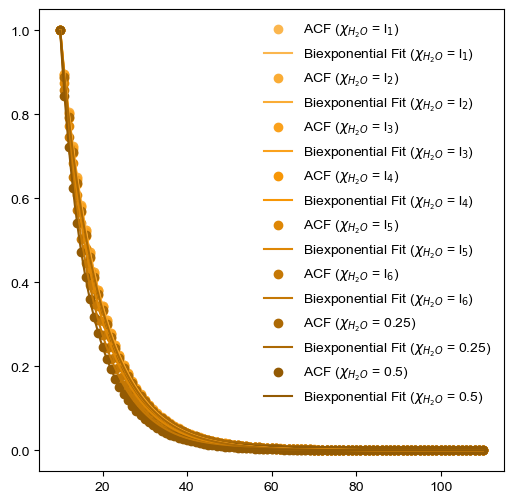

In [44]:
plt.figure(figsize=(6, 6))
plt.scatter(t_acf_dmso_l1_ws, acf_dmso_l1_ws, label="ACF ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.plot(fit_t_dmso_l1_ws, fit_acf_dmso_l1_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmso_1)
plt.scatter(t_acf_dmso_l2_ws, acf_dmso_l2_ws, label="ACF ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.plot(fit_t_dmso_l2_ws, fit_acf_dmso_l2_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmso_2)
plt.scatter(t_acf_dmso_l3_ws, acf_dmso_l3_ws, label="ACF ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.plot(fit_t_dmso_l3_ws, fit_acf_dmso_l3_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmso_3)
plt.scatter(t_acf_dmso_l4_ws, acf_dmso_l4_ws, label="ACF ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.plot(fit_t_dmso_l4_ws, fit_acf_dmso_l4_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmso_4)
plt.scatter(t_acf_dmso_l5_ws, acf_dmso_l5_ws, label="ACF ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.plot(fit_t_dmso_l5_ws, fit_acf_dmso_l5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmso_5)
plt.scatter(t_acf_dmso_l6_ws, acf_dmso_l6_ws, label="ACF ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.plot(fit_t_dmso_l6_ws, fit_acf_dmso_l6_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmso_6)
plt.scatter(t_acf_dmso_0_25_ws, acf_dmso_0_25_ws, label="ACF ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.plot(fit_t_dmso_0_25_ws, fit_acf_dmso_0_25_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmso_7)
plt.scatter(t_acf_dmso_0_5_ws, acf_dmso_0_5_ws, label="ACF ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.plot(fit_t_dmso_0_5_ws, fit_acf_dmso_0_5_ws, label="Biexponential Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmso_8)
plt.legend(frameon=False)

### ACF plot for DMF-water mixtures: using tau_frame = 100 & dt = 10 => finally used

In [20]:
df_dmf_l1 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_l1.csv')
df_dmf_l2 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_l2.csv')
df_dmf_l3 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_l3.csv')
df_dmf_l4 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_l4.csv')
df_dmf_l5 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_l5.csv')
df_dmf_l6 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_l6.csv')
df_dmf_0_25 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_0_25.csv')
df_dmf_0_5 = pd.read_csv('acf-data_frame100_dt10/acf_fit_dmf-water_0_5.csv')
df_dmf_l1

,tau_time_ws,acf_ws,tau_time_ww,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,1.0,1.000000,1.0,1.000000,1.0000,9.999886e-01,1.0000,9.999580e-01
1,2.0,0.444554,2.0,0.745437,1.1001,9.182081e-01,1.1001,9.703725e-01
2,3.0,0.212454,3.0,0.562518,1.2002,8.439885e-01,1.2002,9.418206e-01
3,4.0,0.105090,4.0,0.426471,1.3003,7.765422e-01,1.3003,9.142549e-01
4,5.0,0.053114,5.0,0.324397,1.4004,7.151715e-01,1.4004,8.876309e-01
...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,100.5996,2.474460e-29,100.5996,2.471875e-12
996,NaN,NaN,NaN,NaN,100.6997,2.316692e-29,100.6997,2.406510e-12
997,NaN,NaN,NaN,NaN,100.7998,2.168983e-29,100.7998,2.342873e-12
998,NaN,NaN,NaN,NaN,100.8999,2.030691e-29,100.8999,2.280919e-12


In [21]:
dmf_1 = purple
dmf_2 = gen_color_gradient(purple)
dmf_3 = gen_color_gradient(dmf_2)
dmf_4 = gen_color_gradient(dmf_3)
dmf_5 = gen_color_gradient(dmf_4)
dmf_6 = gen_color_gradient(dmf_5)
dmf_7 = gen_color_gradient(dmf_6)
dmf_8 = gen_color_gradient(dmf_7)

In [22]:
acf_dmf_l1_ws = df_dmf_l1['acf_ws'].loc[df_dmf_l1['acf_ws'].notna()]; acf_dmf_l1_ww = df_dmf_l1['acf_ww'].loc[df_dmf_l1['acf_ww'].notna()]
acf_dmf_l2_ws = df_dmf_l2['acf_ws'].loc[df_dmf_l2['acf_ws'].notna()]; acf_dmf_l2_ww = df_dmf_l2['acf_ww'].loc[df_dmf_l2['acf_ww'].notna()]
acf_dmf_l3_ws = df_dmf_l3['acf_ws'].loc[df_dmf_l3['acf_ws'].notna()]; acf_dmf_l3_ww = df_dmf_l3['acf_ww'].loc[df_dmf_l3['acf_ww'].notna()]
acf_dmf_l4_ws = df_dmf_l4['acf_ws'].loc[df_dmf_l4['acf_ws'].notna()]; acf_dmf_l4_ww = df_dmf_l4['acf_ww'].loc[df_dmf_l4['acf_ww'].notna()]
acf_dmf_l5_ws = df_dmf_l5['acf_ws'].loc[df_dmf_l5['acf_ws'].notna()]; acf_dmf_l5_ww = df_dmf_l5['acf_ww'].loc[df_dmf_l5['acf_ww'].notna()]
acf_dmf_l6_ws = df_dmf_l6['acf_ws'].loc[df_dmf_l6['acf_ws'].notna()]; acf_dmf_l6_ww = df_dmf_l6['acf_ww'].loc[df_dmf_l6['acf_ww'].notna()]
acf_dmf_0_25_ws = df_dmf_0_25['acf_ws'].loc[df_dmf_0_25['acf_ws'].notna()]; acf_dmf_0_25_ww = df_dmf_0_25['acf_ww'].loc[df_dmf_0_25['acf_ww'].notna()]
acf_dmf_0_5_ws = df_dmf_0_5['acf_ws'].loc[df_dmf_0_5['acf_ws'].notna()]; acf_dmf_0_5_ww = df_dmf_0_5['acf_ww'].loc[df_dmf_0_5['acf_ww'].notna()]
acf_dmf_0_5_ww

0      1.000000
1      0.692079
2      0.503965
3      0.373766
4      0.280110
         ...   
96     0.000000
97     0.000000
98     0.000000
99     0.000000
100    0.000000
Name: acf_ww, Length: 101, dtype: float64

In [23]:
fit_t_dmf_l1_ws = df_dmf_l1['fit_t_ws'].loc[df_dmf_l1['fit_t_ws'].notna()]; fit_t_dmf_l1_ww = df_dmf_l1['fit_t_ws'].loc[df_dmf_l1['fit_t_ws'].notna()]
fit_t_dmf_l2_ws = df_dmf_l2['fit_t_ws'].loc[df_dmf_l2['fit_t_ws'].notna()]; fit_t_dmf_l2_ww = df_dmf_l2['fit_t_ws'].loc[df_dmf_l2['fit_t_ws'].notna()]
fit_t_dmf_l3_ws = df_dmf_l3['fit_t_ws'].loc[df_dmf_l3['fit_t_ws'].notna()]; fit_t_dmf_l3_ww = df_dmf_l3['fit_t_ws'].loc[df_dmf_l3['fit_t_ws'].notna()]
fit_t_dmf_l4_ws = df_dmf_l4['fit_t_ws'].loc[df_dmf_l4['fit_t_ws'].notna()]; fit_t_dmf_l4_ww = df_dmf_l4['fit_t_ws'].loc[df_dmf_l4['fit_t_ws'].notna()]
fit_t_dmf_l5_ws = df_dmf_l5['fit_t_ws'].loc[df_dmf_l5['fit_t_ws'].notna()]; fit_t_dmf_l5_ww = df_dmf_l5['fit_t_ws'].loc[df_dmf_l5['fit_t_ws'].notna()]
fit_t_dmf_l6_ws = df_dmf_l6['fit_t_ws'].loc[df_dmf_l6['fit_t_ws'].notna()]; fit_t_dmf_l6_ww = df_dmf_l6['fit_t_ws'].loc[df_dmf_l6['fit_t_ws'].notna()]
fit_t_dmf_0_25_ws = df_dmf_0_25['fit_t_ws'].loc[df_dmf_0_25['fit_t_ws'].notna()]; fit_t_dmf_0_25_ww = df_dmf_0_25['fit_t_ws'].loc[df_dmf_0_25['fit_t_ws'].notna()]
fit_t_dmf_0_5_ws = df_dmf_0_5['fit_t_ws'].loc[df_dmf_0_5['fit_t_ws'].notna()]; fit_t_dmf_0_5_ww = df_dmf_0_5['fit_t_ws'].loc[df_dmf_0_5['fit_t_ws'].notna()]
fit_t_dmf_0_5_ww

0        1.0000
1        1.1001
2        1.2002
3        1.3003
4        1.4004
         ...   
995    100.5996
996    100.6997
997    100.7998
998    100.8999
999    101.0000
Name: fit_t_ws, Length: 1000, dtype: float64

In [24]:
fit_acf_dmf_l1_ws = df_dmf_l1['fit_acf_ws'].loc[df_dmf_l1['fit_acf_ws'].notna()]; fit_acf_dmf_l1_ww = df_dmf_l1['fit_acf_ww'].loc[df_dmf_l1['fit_acf_ww'].notna()]
fit_acf_dmf_l2_ws = df_dmf_l2['fit_acf_ws'].loc[df_dmf_l2['fit_acf_ws'].notna()]; fit_acf_dmf_l2_ww = df_dmf_l2['fit_acf_ww'].loc[df_dmf_l2['fit_acf_ww'].notna()]
fit_acf_dmf_l3_ws = df_dmf_l3['fit_acf_ws'].loc[df_dmf_l3['fit_acf_ws'].notna()]; fit_acf_dmf_l3_ww = df_dmf_l3['fit_acf_ww'].loc[df_dmf_l3['fit_acf_ww'].notna()]
fit_acf_dmf_l4_ws = df_dmf_l4['fit_acf_ws'].loc[df_dmf_l4['fit_acf_ws'].notna()]; fit_acf_dmf_l4_ww = df_dmf_l4['fit_acf_ww'].loc[df_dmf_l4['fit_acf_ww'].notna()]
fit_acf_dmf_l5_ws = df_dmf_l5['fit_acf_ws'].loc[df_dmf_l5['fit_acf_ws'].notna()]; fit_acf_dmf_l5_ww = df_dmf_l5['fit_acf_ww'].loc[df_dmf_l5['fit_acf_ww'].notna()]
fit_acf_dmf_l6_ws = df_dmf_l6['fit_acf_ws'].loc[df_dmf_l6['fit_acf_ws'].notna()]; fit_acf_dmf_l6_ww = df_dmf_l6['fit_acf_ww'].loc[df_dmf_l6['fit_acf_ww'].notna()]
fit_acf_dmf_0_25_ws = df_dmf_0_25['fit_acf_ws'].loc[df_dmf_0_25['fit_acf_ws'].notna()]; fit_acf_dmf_0_25_ww = df_dmf_0_25['fit_acf_ww'].loc[df_dmf_0_25['fit_acf_ww'].notna()]
fit_acf_dmf_0_5_ws = df_dmf_0_5['fit_acf_ws'].loc[df_dmf_0_5['fit_acf_ws'].notna()]; fit_acf_dmf_0_5_ww = df_dmf_0_5['fit_acf_ww'].loc[df_dmf_0_5['fit_acf_ww'].notna()]
fit_acf_dmf_0_5_ww

0      9.996815e-01
1      9.612867e-01
2      9.249640e-01
3      8.905644e-01
4      8.579514e-01
           ...     
995    1.687756e-12
996    1.642738e-12
997    1.598922e-12
998    1.556274e-12
999    1.514763e-12
Name: fit_acf_ww, Length: 1000, dtype: float64

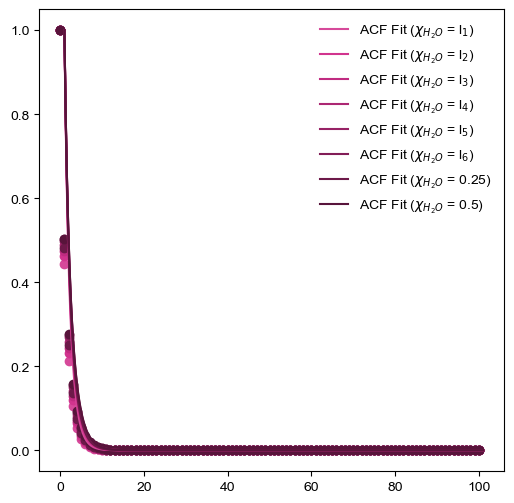

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(np.arange(len(acf_dmf_l1_ws)), acf_dmf_l1_ws, color=dmf_1)
plt.plot(fit_t_dmf_l1_ws, fit_acf_dmf_l1_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_1$)", color=dmf_1)
plt.scatter(np.arange(len(acf_dmf_l2_ws)), acf_dmf_l2_ws, color=dmf_2)
plt.plot(fit_t_dmf_l2_ws, fit_acf_dmf_l2_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_2$)", color=dmf_2)
plt.scatter(np.arange(len(acf_dmf_l3_ws)), acf_dmf_l3_ws, color=dmf_3)
plt.plot(fit_t_dmf_l3_ws, fit_acf_dmf_l3_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_3$)", color=dmf_3)
plt.scatter(np.arange(len(acf_dmf_l4_ws)), acf_dmf_l4_ws, color=dmf_4)
plt.plot(fit_t_dmf_l4_ws, fit_acf_dmf_l4_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_4$)", color=dmf_4)
plt.scatter(np.arange(len(acf_dmf_l5_ws)), acf_dmf_l5_ws, color=dmf_5)
plt.plot(fit_t_dmf_l5_ws, fit_acf_dmf_l5_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_5$)", color=dmf_5)
plt.scatter(np.arange(len(acf_dmf_l6_ws)), acf_dmf_l6_ws, color=dmf_6)
plt.plot(fit_t_dmf_l6_ws, fit_acf_dmf_l6_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_6$)", color=dmf_6)
plt.scatter(np.arange(len(acf_dmf_0_25_ws)), acf_dmf_0_25_ws, color=dmf_7)
plt.plot(fit_t_dmf_0_25_ws, fit_acf_dmf_0_25_ws, label="ACF Fit ($\chi_{H_{2}O}$ = 0.25)", color=dmf_7)
plt.scatter(np.arange(len(acf_dmf_0_5_ws)), acf_dmf_0_5_ws, color=dmf_8)
plt.plot(fit_t_dmf_0_5_ws, fit_acf_dmf_0_5_ws, label="ACF Fit ($\chi_{H_{2}O}$ = 0.5)", color=dmf_8)
plt.legend(frameon=False)

### ACF plot for THF-water mixtures: using tau_frame = 100 & dt = 10 => finally used

In [52]:
# df_thf_l1 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l1.csv')
df_thf_l1 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l1_n.csv')
df_thf_l2 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l2_n.csv')
df_thf_l3 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l3_n.csv')
df_thf_l4 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l4_n.csv')
df_thf_l5 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l5_n.csv')
df_thf_l6 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_l6_n.csv')
df_thf_0_25 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_0_25_n.csv')
df_thf_0_5 = pd.read_csv('acf-data_frame100_dt10/acf_fit_thf-water_0_5_n.csv')
df_thf_l1

,tau_time_ws,acf_ws,tau_time_ww,acf_ww,fit_t_ws,fit_acf_ws,fit_t_ww,fit_acf_ww
0,0.0,1.000000,0.0,1.000000,0.000000,9.999978e-01,0.000000,9.999321e-01
1,10.0,0.419044,10.0,0.579785,1.001001,9.144756e-01,1.001001,9.434205e-01
2,20.0,0.181538,20.0,0.357521,2.002002,8.367972e-01,2.002002,8.909504e-01
3,30.0,0.079391,30.0,0.225260,3.003003,7.661664e-01,3.003003,8.421576e-01
4,40.0,0.035074,40.0,0.143558,4.004004,7.018783e-01,4.004004,7.967164e-01
...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,995.995996,5.556506e-36,995.995996,1.290773e-19
996,NaN,NaN,NaN,NaN,996.996997,5.121662e-36,996.996997,1.235822e-19
997,NaN,NaN,NaN,NaN,997.997998,4.720847e-36,997.997998,1.183211e-19
998,NaN,NaN,NaN,NaN,998.998999,4.351400e-36,998.998999,1.132839e-19


In [47]:
thf_1 = green
thf_2 = gen_color_gradient(green)
thf_3 = gen_color_gradient(thf_2)
thf_4 = gen_color_gradient(thf_3)
thf_5 = gen_color_gradient(thf_4)
thf_6 = gen_color_gradient(thf_5)
thf_7 = gen_color_gradient(thf_6)
thf_8 = gen_color_gradient(thf_7)

In [57]:
t_acf_thf_l1_ws = df_thf_l1['tau_time_ws'].loc[df_thf_l1['tau_time_ws'].notna()]; t_acf_thf_l1_ww = df_thf_l1['tau_time_ww'].loc[df_thf_l1['tau_time_ww'].notna()]
t_acf_thf_l2_ws = df_thf_l2['tau_time_ws'].loc[df_thf_l2['tau_time_ws'].notna()]; t_acf_thf_l2_ww = df_thf_l2['tau_time_ww'].loc[df_thf_l2['tau_time_ww'].notna()]
t_acf_thf_l3_ws = df_thf_l3['tau_time_ws'].loc[df_thf_l3['tau_time_ws'].notna()]; t_acf_thf_l3_ww = df_thf_l3['tau_time_ww'].loc[df_thf_l3['tau_time_ww'].notna()]
t_acf_thf_l4_ws = df_thf_l4['tau_time_ws'].loc[df_thf_l4['tau_time_ws'].notna()]; t_acf_thf_l4_ww = df_thf_l4['tau_time_ww'].loc[df_thf_l4['tau_time_ww'].notna()]
t_acf_thf_l5_ws = df_thf_l5['tau_time_ws'].loc[df_thf_l5['tau_time_ws'].notna()]; t_acf_thf_l5_ww = df_thf_l5['tau_time_ww'].loc[df_thf_l5['tau_time_ww'].notna()]
t_acf_thf_l6_ws = df_thf_l6['tau_time_ws'].loc[df_thf_l6['tau_time_ws'].notna()]; t_acf_thf_l6_ww = df_thf_l6['tau_time_ww'].loc[df_thf_l6['tau_time_ww'].notna()]
t_acf_thf_0_25_ws = df_thf_0_25['tau_time_ws'].loc[df_thf_0_25['tau_time_ws'].notna()]; t_acf_thf_0_25_ww = df_thf_0_25['tau_time_ww'].loc[df_thf_0_25['tau_time_ww'].notna()]
t_acf_thf_0_5_ws = df_thf_0_5['tau_time_ws'].loc[df_thf_0_5['tau_time_ws'].notna()]; t_acf_thf_0_5_ww = df_thf_0_5['tau_time_ww'].loc[df_thf_0_5['tau_time_ww'].notna()]
t_acf_thf_l1_ws

0         0.0
1        10.0
2        20.0
3        30.0
4        40.0
        ...  
96      960.0
97      970.0
98      980.0
99      990.0
100    1000.0
Name: tau_time_ws, Length: 101, dtype: float64

In [53]:
acf_thf_l1_ws = df_thf_l1['acf_ws'].loc[df_thf_l1['acf_ws'].notna()]; acf_thf_l1_ww = df_thf_l1['acf_ww'].loc[df_thf_l1['acf_ww'].notna()]
acf_thf_l2_ws = df_thf_l2['acf_ws'].loc[df_thf_l2['acf_ws'].notna()]; acf_thf_l2_ww = df_thf_l2['acf_ww'].loc[df_thf_l2['acf_ww'].notna()]
acf_thf_l3_ws = df_thf_l3['acf_ws'].loc[df_thf_l3['acf_ws'].notna()]; acf_thf_l3_ww = df_thf_l3['acf_ww'].loc[df_thf_l3['acf_ww'].notna()]
acf_thf_l4_ws = df_thf_l4['acf_ws'].loc[df_thf_l4['acf_ws'].notna()]; acf_thf_l4_ww = df_thf_l4['acf_ww'].loc[df_thf_l4['acf_ww'].notna()]
acf_thf_l5_ws = df_thf_l5['acf_ws'].loc[df_thf_l5['acf_ws'].notna()]; acf_thf_l5_ww = df_thf_l5['acf_ww'].loc[df_thf_l5['acf_ww'].notna()]
acf_thf_l6_ws = df_thf_l6['acf_ws'].loc[df_thf_l6['acf_ws'].notna()]; acf_thf_l6_ww = df_thf_l6['acf_ww'].loc[df_thf_l6['acf_ww'].notna()]
acf_thf_0_25_ws = df_thf_0_25['acf_ws'].loc[df_thf_0_25['acf_ws'].notna()]; acf_thf_0_25_ww = df_thf_0_25['acf_ww'].loc[df_thf_0_25['acf_ww'].notna()]
acf_thf_0_5_ws = df_thf_0_5['acf_ws'].loc[df_thf_0_5['acf_ws'].notna()]; acf_thf_0_5_ww = df_thf_0_5['acf_ww'].loc[df_thf_0_5['acf_ww'].notna()]
acf_thf_0_5_ww

0      1.000000
1      0.306265
2      0.119946
3      0.053200
4      0.025578
         ...   
96     0.000000
97     0.000000
98     0.000000
99     0.000000
100    0.000000
Name: acf_ww, Length: 101, dtype: float64

In [54]:
fit_t_thf_l1_ws = df_thf_l1['fit_t_ws'].loc[df_thf_l1['fit_t_ws'].notna()]; fit_t_thf_l1_ww = df_thf_l1['fit_t_ws'].loc[df_thf_l1['fit_t_ws'].notna()]
fit_t_thf_l2_ws = df_thf_l2['fit_t_ws'].loc[df_thf_l2['fit_t_ws'].notna()]; fit_t_thf_l2_ww = df_thf_l2['fit_t_ws'].loc[df_thf_l2['fit_t_ws'].notna()]
fit_t_thf_l3_ws = df_thf_l3['fit_t_ws'].loc[df_thf_l3['fit_t_ws'].notna()]; fit_t_thf_l3_ww = df_thf_l3['fit_t_ws'].loc[df_thf_l3['fit_t_ws'].notna()]
fit_t_thf_l4_ws = df_thf_l4['fit_t_ws'].loc[df_thf_l4['fit_t_ws'].notna()]; fit_t_thf_l4_ww = df_thf_l4['fit_t_ws'].loc[df_thf_l4['fit_t_ws'].notna()]
fit_t_thf_l5_ws = df_thf_l5['fit_t_ws'].loc[df_thf_l5['fit_t_ws'].notna()]; fit_t_thf_l5_ww = df_thf_l5['fit_t_ws'].loc[df_thf_l5['fit_t_ws'].notna()]
fit_t_thf_l6_ws = df_thf_l6['fit_t_ws'].loc[df_thf_l6['fit_t_ws'].notna()]; fit_t_thf_l6_ww = df_thf_l6['fit_t_ws'].loc[df_thf_l6['fit_t_ws'].notna()]
fit_t_thf_0_25_ws = df_thf_0_25['fit_t_ws'].loc[df_thf_0_25['fit_t_ws'].notna()]; fit_t_thf_0_25_ww = df_thf_0_25['fit_t_ws'].loc[df_thf_0_25['fit_t_ws'].notna()]
fit_t_thf_0_5_ws = df_thf_0_5['fit_t_ws'].loc[df_thf_0_5['fit_t_ws'].notna()]; fit_t_thf_0_5_ww = df_thf_0_5['fit_t_ws'].loc[df_thf_0_5['fit_t_ws'].notna()]
fit_t_thf_0_5_ww

0         0.000000
1         1.001001
2         2.002002
3         3.003003
4         4.004004
          ...     
995     995.995996
996     996.996997
997     997.997998
998     998.998999
999    1000.000000
Name: fit_t_ws, Length: 1000, dtype: float64

In [55]:
fit_acf_thf_l1_ws = df_thf_l1['fit_acf_ws'].loc[df_thf_l1['fit_acf_ws'].notna()]; fit_acf_thf_l1_ww = df_thf_l1['fit_acf_ww'].loc[df_thf_l1['fit_acf_ww'].notna()]
fit_acf_thf_l2_ws = df_thf_l2['fit_acf_ws'].loc[df_thf_l2['fit_acf_ws'].notna()]; fit_acf_thf_l2_ww = df_thf_l2['fit_acf_ww'].loc[df_thf_l2['fit_acf_ww'].notna()]
fit_acf_thf_l3_ws = df_thf_l3['fit_acf_ws'].loc[df_thf_l3['fit_acf_ws'].notna()]; fit_acf_thf_l3_ww = df_thf_l3['fit_acf_ww'].loc[df_thf_l3['fit_acf_ww'].notna()]
fit_acf_thf_l4_ws = df_thf_l4['fit_acf_ws'].loc[df_thf_l4['fit_acf_ws'].notna()]; fit_acf_thf_l4_ww = df_thf_l4['fit_acf_ww'].loc[df_thf_l4['fit_acf_ww'].notna()]
fit_acf_thf_l5_ws = df_thf_l5['fit_acf_ws'].loc[df_thf_l5['fit_acf_ws'].notna()]; fit_acf_thf_l5_ww = df_thf_l5['fit_acf_ww'].loc[df_thf_l5['fit_acf_ww'].notna()]
fit_acf_thf_l6_ws = df_thf_l6['fit_acf_ws'].loc[df_thf_l6['fit_acf_ws'].notna()]; fit_acf_thf_l6_ww = df_thf_l6['fit_acf_ww'].loc[df_thf_l6['fit_acf_ww'].notna()]
fit_acf_thf_0_25_ws = df_thf_0_25['fit_acf_ws'].loc[df_thf_0_25['fit_acf_ws'].notna()]; fit_acf_thf_0_25_ww = df_thf_0_25['fit_acf_ww'].loc[df_thf_0_25['fit_acf_ww'].notna()]
fit_acf_thf_0_5_ws = df_thf_0_5['fit_acf_ws'].loc[df_thf_0_5['fit_acf_ws'].notna()]; fit_acf_thf_0_5_ww = df_thf_0_5['fit_acf_ww'].loc[df_thf_0_5['fit_acf_ww'].notna()]
fit_acf_thf_0_5_ww

0      9.999894e-01
1      8.776221e-01
2      7.722878e-01
3      6.814372e-01
4      6.029163e-01
           ...     
995    7.207871e-31
996    6.728465e-31
997    6.280944e-31
998    5.863189e-31
999    5.473219e-31
Name: fit_acf_ww, Length: 1000, dtype: float64

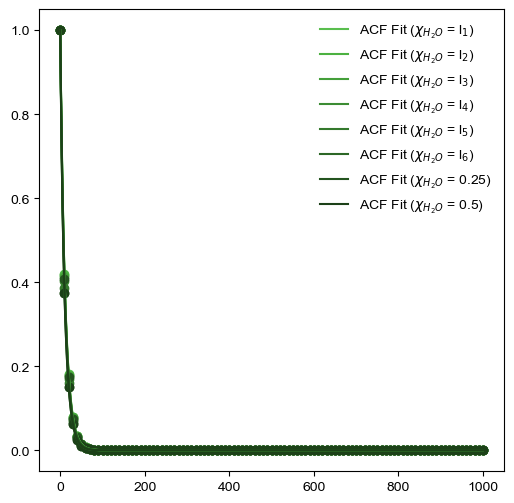

In [58]:
plt.figure(figsize=(6, 6))
plt.scatter(t_acf_thf_l1_ws, acf_thf_l1_ws, color=thf_1)
plt.plot(fit_t_thf_l1_ws, fit_acf_thf_l1_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_1$)", color=thf_1)
plt.scatter(t_acf_thf_l2_ws, acf_thf_l2_ws, color=thf_2)
plt.plot(fit_t_thf_l2_ws, fit_acf_thf_l2_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_2$)", color=thf_2)
plt.scatter(t_acf_thf_l3_ws, acf_thf_l3_ws, color=thf_3)
plt.plot(fit_t_thf_l3_ws, fit_acf_thf_l3_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_3$)", color=thf_3)
plt.scatter(t_acf_thf_l4_ws, acf_thf_l4_ws, color=thf_4)
plt.plot(fit_t_thf_l4_ws, fit_acf_thf_l4_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_4$)", color=thf_4)
plt.scatter(t_acf_thf_l5_ws, acf_thf_l5_ws, color=thf_5)
plt.plot(fit_t_thf_l5_ws, fit_acf_thf_l5_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_5$)", color=thf_5)
plt.scatter(t_acf_thf_l6_ws, acf_thf_l6_ws, color=thf_6)
plt.plot(fit_t_thf_l6_ws, fit_acf_thf_l6_ws, label="ACF Fit ($\chi_{H_{2}O}$ = l$_6$)", color=thf_6)
plt.scatter(t_acf_thf_0_25_ws, acf_thf_0_25_ws, color=thf_7)
plt.plot(fit_t_thf_0_25_ws, fit_acf_thf_0_25_ws, label="ACF Fit ($\chi_{H_{2}O}$ = 0.25)", color=thf_7)
plt.scatter(t_acf_thf_0_5_ws, acf_thf_0_5_ws, color=thf_8)
plt.plot(fit_t_thf_0_5_ws, fit_acf_thf_0_5_ws, label="ACF Fit ($\chi_{H_{2}O}$ = 0.5)", color=thf_8)
plt.legend(frameon=False)